In [199]:
import h5py
import os
import json, pickle, hashlib
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import PowerNorm

from datetime import datetime, timezone

import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
save_path = "/Volumes/SSD/mark/Documents/Works/Статья восстановление маршрутов/Графики"

In [3]:
dataset_path = "/Volumes/SSD/mark/Documents/Works/MT_Dataset/mt_tracks_20250714_tsorted.h5"

if "ds" in vars():
    ds.close()   # type: ignore

ds = h5py.File(dataset_path, "r")
for attr in ds.attrs:
    print(f"{attr}: {ds.attrs[attr]}")

author: Mark Vodyanitskiy (mvodya@icloud.com)
created_at: 2025-07-13T14:26:08.378871
filter_rules: MIN_TOTAL_POINTS=50, MIN_MOVING_POINTS=5, MIN_MAX_SPEED=20, SPEED_MOVING_MIN=10, SPEED_SANITY_MAX=800
filtered_at: 2026-01-08T06:02:47.931391
sources_count: 27555
sources_size: 439.3Gb
tracks_built_at: 2026-01-09T17:19:14.225437
tracks_count: 11731643
tracks_rules: SPEED_MOVING_MIN=10, STOP_RADIUS_M=250.0, STOP_DWELL_SEC=1800, GAP_HARD_SEC=18000, GAP_VERY_HARD_SEC=36000, DIST_AFTER_GAP_M=150000.0, JUMP_HARD_M=250000.0, DEST_GAP_SEC=14400, DEST_DIST_M=50000.0
tsorted_built_at: b'2026-01-12T10:46:51'
version: 1.0


In [4]:
def haversine_m_vec(lat1, lon1, lat2, lon2):
    """
    Векторная haversine (метры). lat/lon в градусах, numpy arrays
    """
    R = 6371000.0
    lat1 = np.deg2rad(lat1); lon1 = np.deg2rad(lon1)
    lat2 = np.deg2rad(lat2); lon2 = np.deg2rad(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return 2.0 * R * np.arcsin(np.sqrt(a))

# Индекс по HDF5 dataset'ам внутри /positions/tracks
# [(min_track_id, max_track_id, h5_path, dataset_obj)]
track_positions_index = None

def build_track_positions_index(ds, root="/positions/tracks"):
    """
    Проходит по всем dataset'ам под root и строит индекс по диапазонам track_id
    (берем dset[0].track_id и dset[-1].track_id)
    """
    items = []
    grp = ds[root]

    # соберем все датасеты (листья)
    # NOTE: visititems вызывает callback для всех объектов под деревом
    leaves = []
    def _cb(name, obj):
        # name относительный от root
        if isinstance(obj, type(grp)) and hasattr(obj, "keys"):
            return
        # h5py Dataset
        if hasattr(obj, "shape") and hasattr(obj, "dtype"):
            leaves.append((f"{root}/{name}", obj))

    grp.visititems(_cb)

    for path, dset in tqdm(leaves, desc="Index /positions/tracks leaves"):
        if dset.shape[0] == 0:
            continue
        # читаем только 2 строки
        a = int(dset[0]["track_id"])
        b = int(dset[-1]["track_id"])
        lo, hi = (a, b) if a <= b else (b, a)
        items.append((lo, hi, path, dset))

    items.sort(key=lambda x: x[0])
    return items

def ensure_track_positions_index(ds):
    global track_positions_index
    if track_positions_index is None:
        track_positions_index = build_track_positions_index(ds)
    return track_positions_index

def get_track_points(ds, track_id: int):
    """
    Возвращает np structured array с точками трека из /positions/tracks/**
    Ищем нужный leaf по диапазонам track_id
    """
    idx = ensure_track_positions_index(ds)

    # бинарный поиск по min_track_id
    mins = np.fromiter((x[0] for x in idx), dtype=np.int64, count=len(idx))
    pos = int(np.searchsorted(mins, track_id, side="right") - 1)
    if pos < 0:
        raise KeyError(f"track_id {track_id} not found in /positions/tracks index (pos<0)")

    # иногда track_id может попасть в следующий диапазон — проверим несколько соседей
    for j in [pos, pos+1, pos-1, pos+2, pos-2]:
        if 0 <= j < len(idx):
            lo, hi, path, dset = idx[j]
            if lo <= track_id <= hi:
                # в dset внутри обычно отсортировано по track_id, можно быстро выбрать маской
                # но чтобы не читать всё — сначала сузим по track_id через поиск границ
                tcol = dset["track_id"]  # h5py поддерживает чтение поля как "virtual" array
                # Однако binary search по h5py полю напрямую не всегда быстрый; делаем read track_id колонкой кусками
                # Для простоты/надежности: читаем небольшой диапазон вокруг найденного track_id через chunk-scan
                # Но чаще всего dset не гигантский; попробуем прочитать целиком track_id и найти диапазон.
                tids = np.asarray(tcol, dtype=np.int64)
                m = (tids == track_id)
                if not np.any(m):
                    continue
                return dset[m]

    raise KeyError(f"track_id {track_id} not found (index hit but no rows).")


In [5]:
poi_path = Path(ds.filename).with_name(Path(ds.filename).stem.replace("_tsorted", "") + "_poi.json")
print("POI JSON:", poi_path, "(exists:", poi_path.exists(), ")")
with open(poi_path, "r", encoding="utf-8") as f:
    poi = json.load(f)
    print(f"Number of POIs: {len(poi["pois"])}")
    poi_track_quality = poi.get("track_quality", {})
    poi_track_ids = np.fromiter((int(k) for k in poi_track_quality.keys()), dtype=np.int64)
    print(f"Number of POI tracks: {len(poi_track_ids)}")

POI JSON: /Volumes/SSD/mark/Documents/Works/MT_Dataset/mt_tracks_20250714_poi.json (exists: True )
Number of POIs: 216
Number of POI tracks: 380072


Build df from track_quality: 100%|██████████| 380072/380072 [00:00<00:00, 2627290.66it/s]


   track_id  points_seen  max_gap_sec  max_gap_dist_m
0       161           40        22051    20841.253906
1       948          160         9624    89208.234375
2      1233           38         5478    28029.214844
3      1284          196        10922   167795.906250
4      1323           51         9464    54691.089844
           track_id    points_seen    max_gap_sec  max_gap_dist_m
count  3.800720e+05  380072.000000  380072.000000   380072.000000
mean   7.413479e+06      94.404929    7799.503134    73090.260792
std    3.976349e+06      97.853496    8496.503133    61378.838195
min    1.610000e+02       2.000000     546.000000     1655.760742
50%    7.397586e+06      64.000000    3800.000000    54102.054688
90%    1.283772e+07     219.000000   21594.900000   168113.217188
95%    1.337979e+07     283.000000   27357.000000   198378.353906
99%    1.378613e+07     443.000000   34185.290000   237172.547031
max    1.394758e+07    2122.000000   36000.000000   249996.171875


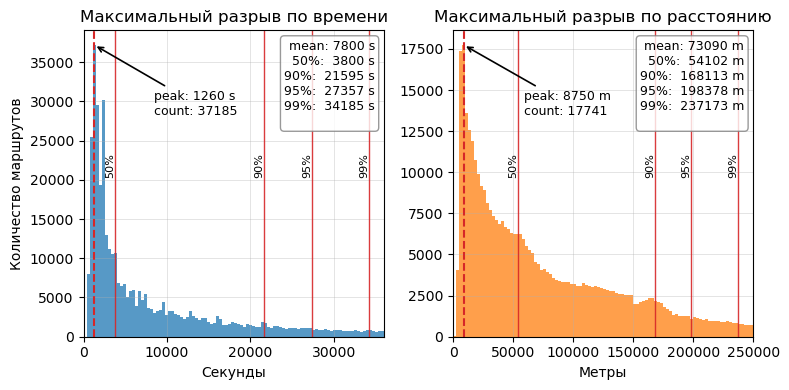

In [6]:
rows = []

for k, v in tqdm(poi_track_quality.items(), total=len(poi_track_quality), desc="Build df from track_quality"):
    rows.append((int(k), int(v.get("points_seen", 0)), int(v.get("max_gap_sec", 0)), float(v.get("max_gap_dist_m", 0.0))))

qdf = pd.DataFrame(rows, columns=["track_id", "points_seen", "max_gap_sec", "max_gap_dist_m"])
qdf.sort_values("track_id", inplace=True)
qdf.reset_index(drop=True, inplace=True)
print(qdf.head())
print(qdf.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

clip_sec  = 36_000
clip_dist = 250_000
bins_sec  = 100
bins_dist = 100

sec_all  = qdf["max_gap_sec"].to_numpy(dtype=np.float64)
dist_all = qdf["max_gap_dist_m"].to_numpy(dtype=np.float64)

sec  = np.clip(sec_all,  0, clip_sec)
dist = np.clip(dist_all, 0, clip_dist)

def _hist_with_peak(ax, data, bins, clip_max, color, title, xlabel, unit):
    counts, edges = np.histogram(data, bins=bins, range=(0, clip_max))
    centers = 0.5 * (edges[:-1] + edges[1:])

    ax.bar(centers, counts, width=np.diff(edges), align="center",
           color=color, alpha=0.75, edgecolor="none")

    # ax.set_yscale("log")

    # Peak
    peak_i = int(np.argmax(counts))
    peak_x = centers[peak_i]
    peak_y = counts[peak_i]

    ax.axvline(peak_x, linestyle="--", linewidth=1.5, color="tab:red")
    ax.annotate(
        f"peak: {peak_x:.0f} {unit}\ncount: {peak_y:.0f}",
        xy=(peak_x, peak_y),
        xytext=(peak_x + 0.2 * clip_max, peak_y - 0.25 * peak_y),
        arrowprops=dict(arrowstyle="->", linewidth=1.2),
        fontsize=9,
        ha="left",
        va="bottom",
    )

    # Statistics
    p50, p90, p95, p99 = np.percentile(data, [50, 90, 95, 99])
    mean = float(np.mean(data))

    for x, lab in [(p50, "50%"), (p90, "90%"), (p95, "95%"), (p99, "99%")]:
        ax.axvline(x, linewidth=1.0, alpha=0.9, color="tab:red")
        ax.text(x, ax.get_ylim()[1] * 0.6, lab, rotation=90, va="top", ha="right", fontsize=8)

    txt = (
        f"mean: {mean:.0f} {unit}\n"
        f"50%:  {p50:.0f} {unit}\n"
        f"90%:  {p90:.0f} {unit}\n"
        f"95%:  {p95:.0f} {unit}\n"
        f"99%:  {p99:.0f} {unit}\n"
    )
    ax.text(
        0.97, 0.97, txt,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=9,
        bbox=dict(boxstyle="round", alpha=0.8, color="white", ec="gray")
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Количество маршрутов")
    ax.grid(True, which="both", linewidth=0.6, alpha=0.4)
    ax.set_xlim(0, clip_max)

# Plot
fig = plt.figure(figsize=(8, 4))
ax1 = fig.add_subplot(1, 2, 1)
_hist_with_peak(
    ax1, sec, bins_sec, clip_sec,
    color="tab:blue",
    title="Максимальный разрыв по времени",
    xlabel="Секунды",
    unit="s",
)

ax2 = fig.add_subplot(1, 2, 2)
_hist_with_peak(
    ax2, dist, bins_dist, clip_dist,
    color="tab:orange",
    title="Максимальный разрыв по расстоянию",
    xlabel="Метры",
    unit="m",
)
ax2.set_ylabel("")

fig.tight_layout()

plt.savefig(f"{save_path}/time_and_dist_gaps.png", dpi=200)
plt.savefig(f"{save_path}/time_and_dist_gaps.pdf", dpi=200)

plt.show()

In [7]:
def radius_bbox_deg(lat_c, lon_c, radius_m):
    """
    Грубый bbox в градусах для ускоряющего фильтра
    """
    # 1 deg lat ~ 111.32 km
    dlat = radius_m / 111_320.0
    # 1 deg lon ~ 111.32 km * cos(lat)
    dlon = radius_m / max(1e-6, (111_320.0 * np.cos(np.deg2rad(lat_c))))
    return (lat_c - dlat, lat_c + dlat, lon_c - dlon, lon_c + dlon)

def find_tracks_start_end_in_radius(
    ds,
    start_center_latlon,
    end_center_latlon,
    radius_m=30_000.0,
    chunk_rows=2_000_000,
    min_points=0,
    time_min=None,   # unix ts int, optional
    time_max=None,   # unix ts int, optional
):
    """
    Ищем треки, у которых (start_lat, start_lon) в радиусе от start_center,
    и (end_lat, end_lon) в радиусе от end_center
    Возвращает DataFrame кандидатов с дистанциями и базовыми полями
    """
    tr = ds["tracks"]  # structured array
    n = tr.shape[0]

    s_latc, s_lonc = map(float, start_center_latlon)
    e_latc, e_lonc = map(float, end_center_latlon)
    radius_m = float(radius_m)

    s_lat0, s_lat1, s_lon0, s_lon1 = radius_bbox_deg(s_latc, s_lonc, radius_m)
    e_lat0, e_lat1, e_lon0, e_lon1 = radius_bbox_deg(e_latc, e_lonc, radius_m)

    out = []

    pbar = tqdm(range(0, n, chunk_rows), total=(n + chunk_rows - 1)//chunk_rows, desc="Scan ds['tracks']")
    for i0 in pbar:
        i1 = min(n, i0 + chunk_rows)
        chunk = tr[i0:i1]

        # базовые фильтры
        if min_points > 0:
            m = chunk["points_count"] >= int(min_points)
            chunk = chunk[m]
            if chunk.shape[0] == 0:
                continue

        if time_min is not None:
            m = chunk["start_timestamp"] >= int(time_min)
            chunk = chunk[m]
            if chunk.shape[0] == 0:
                continue

        if time_max is not None:
            m = chunk["end_timestamp"] <= int(time_max)
            chunk = chunk[m]
            if chunk.shape[0] == 0:
                continue

        # bbox start
        slat = chunk["start_lat"].astype(np.float64)
        slon = chunk["start_lon"].astype(np.float64)
        elat = chunk["end_lat"].astype(np.float64)
        elon = chunk["end_lon"].astype(np.float64)

        m_s = (slat >= s_lat0) & (slat <= s_lat1) & (slon >= s_lon0) & (slon <= s_lon1)
        if not np.any(m_s):
            continue
        chunk2 = chunk[m_s]
        slat2 = slat[m_s]; slon2 = slon[m_s]
        elat2 = elat[m_s]; elon2 = elon[m_s]

        # bbox end
        m_e = (elat2 >= e_lat0) & (elat2 <= e_lat1) & (elon2 >= e_lon0) & (elon2 <= e_lon1)
        if not np.any(m_e):
            continue

        chunk3 = chunk2[m_e]
        slat3 = slat2[m_e]; slon3 = slon2[m_e]
        elat3 = elat2[m_e]; elon3 = elon2[m_e]

        # точная дистанция
        d_start = haversine_m_vec(slat3, slon3, np.full_like(slat3, s_latc), np.full_like(slon3, s_lonc))
        d_end   = haversine_m_vec(elat3, elon3, np.full_like(elat3, e_latc), np.full_like(elon3, e_lonc))

        m_ok = (d_start <= radius_m) & (d_end <= radius_m)
        if not np.any(m_ok):
            continue

        chunk4 = chunk3[m_ok]
        d_start = d_start[m_ok]
        d_end = d_end[m_ok]

        # собираем результат
        for row, ds0, de0 in zip(chunk4, d_start, d_end):
            out.append((
                int(row["track_id"]),
                int(row["ship_id"]),
                int(row["start_timestamp"]),
                int(row["end_timestamp"]),
                float(row["start_lat"]), float(row["start_lon"]),
                float(row["end_lat"]), float(row["end_lon"]),
                int(row["points_count"]),
                float(ds0), float(de0),
            ))

    cols = [
        "track_id","ship_id","start_ts","end_ts",
        "start_lat","start_lon","end_lat","end_lon",
        "points_count","dist_start_m","dist_end_m"
    ]
    df = pd.DataFrame(out, columns=cols)
    if len(df):
        df.sort_values(["points_count","dist_start_m","dist_end_m"], ascending=[False, True, True], inplace=True)
        df.reset_index(drop=True, inplace=True)
    return df

start_center = (43.10, 131.90) # Владивосток
end_center   = (42.80, 132.90) # Находка

cand = find_tracks_start_end_in_radius(
    ds,
    start_center, end_center,
    radius_m=25_000,
    chunk_rows=2_000_000,
    min_points=50,
)

cand.head(20)

Scan ds['tracks']: 100%|██████████| 6/6 [00:02<00:00,  2.64it/s]


,track_id,ship_id,start_ts,end_ts,start_lat,start_lon,end_lat,end_lon,points_count,dist_start_m,dist_end_m
0,4476796,1900735,1737268237,1737968731,43.083931,131.998505,42.807331,132.770996,1052,8195.817317,10555.945116
1,6870103,11924,1741212342,1741353655,43.074650,132.009140,42.705132,132.725937,202,9300.406205,17699.289282
2,9482176,55,1744827929,1744971042,43.065868,131.763657,42.784283,132.931808,201,11705.212798,3129.051985
3,3470416,24,1735782636,1735919140,43.064651,132.023102,42.800030,132.928696,189,10742.469092,2341.197206
4,7982000,24554,1742821532,1742927188,43.097324,131.876358,42.660400,133.023499,173,1942.461062,18512.388467
5,13383636,43152484,1751233836,1751342736,43.038425,131.937607,42.828705,132.953568,173,7497.362379,5411.048579
6,7971031,18413,1742806531,1742910712,43.079510,131.870636,42.681843,132.975815,171,3298.011533,14524.227182
7,8159456,18490,1743051332,1743157539,43.108784,131.901306,42.861012,132.732346,170,982.444714,15262.362719
8,13812950,18471,1751907033,1752010846,43.082615,131.886063,42.826195,132.915146,168,2240.055595,3163.904365
9,8085033,20468418,1742954734,1743058302,43.039051,131.938553,42.603050,132.923203,167,7465.789887,21981.738598


In [8]:
start_center = (34.69306, 135.4385) # Осака
end_center   = (34.37628, 132.4554) # Хиросима

cand = find_tracks_start_end_in_radius(
    ds,
    start_center, end_center,
    radius_m=25_000,
    chunk_rows=2_000_000,
    min_points=50,
)

cand.head(20)

Scan ds['tracks']: 100%|██████████| 6/6 [00:02<00:00,  2.87it/s]


,track_id,ship_id,start_ts,end_ts,start_lat,start_lon,end_lat,end_lon,points_count,dist_start_m,dist_end_m
0,9824598,15347,1745240228,1745641655,34.667236,135.294479,34.230621,132.505142,613,13478.685454,16828.628933
1,4687101,23819,1737564724,1737794235,34.587940,135.445999,34.355759,132.445602,311,11708.902586,2452.676624
2,8409373,21131,1743414177,1743630448,34.548340,135.352768,34.240974,132.543808,310,17902.535953,17096.709131
3,6149096,21775,1740121629,1740295658,34.662075,135.236679,34.359005,132.520401,273,18773.963906,6267.657672
4,2910361,9908,1734505019,1734705150,34.678101,135.280502,34.327068,132.466003,270,14541.836271,5557.991797
5,11868913,21732,1748308021,1748466759,34.644039,135.400986,34.350273,132.356186,250,6440.676576,9554.852985
6,4905998,21659,1737988928,1738196247,34.672020,135.247604,34.355068,132.434219,245,17611.112487,3056.579140
7,7045303,555319,1741469822,1741629167,34.587715,135.435989,34.331768,132.500443,241,11716.064542,6449.384942
8,5114752,21526,1738449118,1738600637,34.598881,135.411499,34.219891,132.609894,238,10759.597529,22445.689243
9,5690596,23622,1739441523,1739603248,34.667080,135.444199,34.241951,132.552902,226,2935.471904,17415.622241


In [9]:
start_center = (34.69306, 135.4385) # Осака
end_center   = (33.812605, 132.7425123) # Мацуяма

cand = find_tracks_start_end_in_radius(
    ds,
    start_center, end_center,
    radius_m=25_000,
    chunk_rows=2_000_000,
    min_points=50,
)

cand.head(20)

Scan ds['tracks']: 100%|██████████| 6/6 [00:02<00:00,  2.79it/s]


,track_id,ship_id,start_ts,end_ts,start_lat,start_lon,end_lat,end_lon,points_count,dist_start_m,dist_end_m
0,5394052,20102,1738983126,1739269235,34.632278,135.462204,33.862320,132.708206,451,7097.795870,6371.733157
1,10412401,21436,1745978527,1746254554,34.585892,135.423889,33.863010,132.703461,414,11991.301137,6665.075916
2,11031789,20388,1746957743,1747254792,34.648335,135.412781,33.859783,132.670990,412,5501.389863,8435.571967
3,5506884,8249,1739167922,1739393246,34.584820,135.423798,33.861912,132.676697,356,12110.687091,8186.040285
4,13743787,21403,1751787726,1752008604,34.579441,135.424927,33.986572,132.757721,348,12694.730703,19395.136656
5,4299928,21647,1737006423,1737223626,34.586342,135.422897,33.864769,132.667206,330,11952.057965,9056.490942
6,3868197,20102,1736394731,1736605521,34.646610,135.431198,33.815430,132.554199,304,5207.963676,17400.347722
7,7325770,20102,1741834322,1742036625,34.646347,135.317856,33.871307,132.534714,281,12194.660853,20271.107890
8,10016395,23455,1745474523,1745644472,34.551708,135.420547,33.914886,132.516434,265,15803.212122,23771.585388
9,13123031,21004,1750837326,1750971872,34.696205,135.394867,33.815807,132.534882,215,4004.416900,19185.454906


In [131]:
start_center = (35.6480637, 139.7846339) # Токио
end_center   = (35.0655227, 136.8163018) # Нагоя

cand = find_tracks_start_end_in_radius(
    ds,
    start_center, end_center,
    radius_m=25_000,
    chunk_rows=2_000_000,
    min_points=50,
)

cand.head(60)

Scan ds['tracks']: 100%|██████████| 6/6 [00:02<00:00,  2.34it/s]


,track_id,ship_id,start_ts,end_ts,start_lat,start_lon,end_lat,end_lon,points_count,dist_start_m,dist_end_m
0,8266745,20780,1743210370,1743684107,35.475208,139.646469,34.997307,136.833206,699,22926.594489,7739.841803
1,10080986,20780,1745554560,1746010891,35.489319,139.678268,34.997173,136.833069,689,20103.097906,7751.920040
2,13059134,21056,1750745168,1751200596,35.477337,139.687469,34.998253,136.833038,648,20919.769020,7633.708854
3,11191221,154261,1747207560,1747612297,35.674583,139.957336,35.012882,136.844482,591,15878.742713,6390.941268
4,6009111,20780,1739916073,1740229929,35.488178,139.679092,34.998192,136.833740,489,20179.220874,7653.361981
5,8284700,6775,1743233756,1743485489,35.461899,139.705673,34.885521,136.726578,392,21898.349390,21620.410916
6,8670154,60304314,1743764766,1744008992,35.463047,139.703049,34.990452,136.669815,387,21856.703134,15734.988708
7,9140840,3759069,1744347956,1744582892,35.463634,139.703003,35.051556,136.880585,368,21796.621661,6053.663076
8,6147126,250100,1740118572,1740348694,35.453285,139.681274,35.051559,136.880707,368,23590.717601,6064.294009
9,9062158,19872,1744255258,1744483625,35.662773,139.994919,34.958736,136.732666,354,19069.518885,14107.123150


Index /positions/tracks leaves: 100%|██████████| 13781/13781 [00:03<00:00, 4045.76it/s]


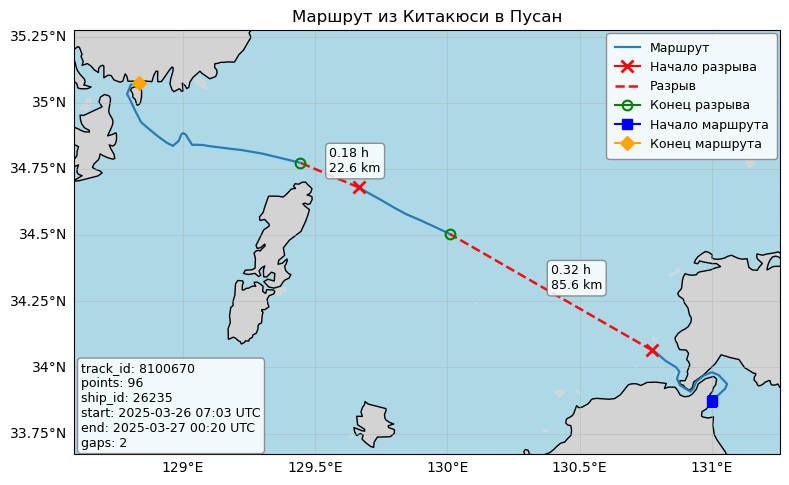

[{'i': 30,
  'dt_sec': 1159,
  'dist_m': 85583.45085536505,
  'a_lat': 34.06510925292969,
  'a_lon': 130.77456665039062,
  'b_lat': 34.50477600097656,
  'b_lon': 130.00997924804688},
 {'i': 42,
  'dt_sec': 642,
  'dist_m': 22614.257252070984,
  'a_lat': 34.681453704833984,
  'a_lon': 129.66383361816406,
  'b_lat': 34.774559020996094,
  'b_lon': 129.44383239746094}]

In [10]:
def compute_track_gaps(points, min_gap_sec=3600, min_gap_dist_m=20000.0):
    """
    Разрыв между i и i+1, если:
      dt_sec >= min_gap_sec  ИЛИ  dist_m >= min_gap_dist_m
    dt считаем по timestamp diff
    """
    ts  = points["timestamp"].astype(np.int64)
    lat = points["lat"].astype(np.float64)
    lon = points["lon"].astype(np.float64)

    n = len(ts)
    if n < 2:
        return []

    # dt между соседями
    dt = np.diff(ts)  # длина n-1

    # dist между соседями
    dist = haversine_m_vec(lat[:-1], lon[:-1], lat[1:], lon[1:])  # длина n-1

    m = (dt >= int(min_gap_sec)) | (dist >= float(min_gap_dist_m))
    idx = np.nonzero(m)[0]  # i, где разрыв между i и i+1

    gaps = []
    for i in idx.tolist():
        gaps.append({
            "i": int(i),
            "dt_sec": int(dt[i]),
            "dist_m": float(dist[i]),
            "a_lat": float(lat[i]),
            "a_lon": float(lon[i]),
            "b_lat": float(lat[i+1]),
            "b_lon": float(lon[i+1]),
        })
    return gaps

def set_map_style(ax):
    ax.coastlines(resolution="10m")
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    gl = ax.gridlines(draw_labels=True, alpha=0.5, linewidth=0.6)
    gl.top_labels = False
    gl.right_labels = False

def plot_track_with_gaps(
    ds,
    track_id: int,
    min_gap_sec=3600,
    min_gap_dist_m=20000.0,
    pad_deg=0.25,
    save_path=None,
    title="Маршрут с разрывыми",
    ax=None,
):
    """
    Рисует трек: сегменты — сплошная линия, разрывы — X -> красный пунктир -> O
    рядом подпись времени/расстояния разрыва
    """
    pts = get_track_points(ds, int(track_id))

    lat = pts["lat"].astype(np.float64)
    lon = pts["lon"].astype(np.float64)
    ts  = pts["timestamp"].astype(np.int64)

    gaps = compute_track_gaps(pts, min_gap_sec=min_gap_sec, min_gap_dist_m=min_gap_dist_m)

    # extent по треку
    min_lon, max_lon = float(lon.min()), float(lon.max())
    min_lat, max_lat = float(lat.min()), float(lat.max())
    extent = (min_lon - pad_deg, max_lon + pad_deg, min_lat - pad_deg, max_lat + pad_deg)

    if ax == None:
        local_ax = True
        fig = plt.figure(figsize=(8, 5))
        ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    else:
        local_ax = False
    
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    set_map_style(ax)

    # Рисуем сегменты между разрывами
    # индексы разрывов: разрыв между i и i+1 => граница сегмента после i
    cut = [g["i"] for g in gaps]
    cut = sorted(set(cut))

    start_idx = 0
    for i in cut:
        end_idx = i + 1
        ax.plot(lon[start_idx:end_idx], lat[start_idx:end_idx],
                color="tab:blue",
                linewidth=1.6, alpha=0.95, transform=ccrs.PlateCarree(),
                label="Маршрут" if start_idx == 0 else None)
        start_idx = end_idx

    # Последний сегмент
    ax.plot(lon[start_idx:], lat[start_idx:],
            color="tab:blue",
            linewidth=1.6, alpha=0.95, transform=ccrs.PlateCarree(),
            label=None)

    # Разрывы
    first_gap = True
    for g in gaps:
        ax.plot(g["a_lon"], g["a_lat"], marker="x", markersize=9,
                color="red",
                markeredgewidth=2.0, transform=ccrs.PlateCarree(),
                label="Начало разрыва" if first_gap else None)

        ax.plot([g["a_lon"], g["b_lon"]], [g["a_lat"], g["b_lat"]],
                linestyle="--", linewidth=1.8, alpha=0.95, color="red",
                transform=ccrs.PlateCarree(),
                label="Разрыв" if first_gap else None)

        ax.plot(g["b_lon"], g["b_lat"], marker="o", markersize=7,
                color="green",
                markeredgewidth=1.5, markerfacecolor="none",
                transform=ccrs.PlateCarree(),
                label="Конец разрыва" if first_gap else None)

        # Подпись около середины
        mid_lon = 0.5 * (g["a_lon"] + g["b_lon"])
        mid_lat = 0.5 * (g["a_lat"] + g["b_lat"])

        dt_h = g["dt_sec"] / 3600.0
        dist_km = g["dist_m"] / 1000.0

        txt = f"{dt_h:.2f} h\n{dist_km:.1f} km"
        ax.text(
            mid_lon, mid_lat, txt,
            transform=ccrs.PlateCarree(),
            fontsize=9, ha="left", va="bottom",
            bbox=dict(boxstyle="round", alpha=0.85, color="white", ec="gray"),
        )
        first_gap = False

    # Старт/финиш
    ax.plot(lon[0], lat[0], marker="s", markersize=7, color="blue", transform=ccrs.PlateCarree(), label="Начало маршрута")
    ax.plot(lon[-1], lat[-1], marker="D", markersize=7, color="orange", transform=ccrs.PlateCarree(), label="Конец маршрута")

    # Инфо-блок
    ship_id = int(pts["ship_id"][0]) if "ship_id" in pts.dtype.names else None
    n = len(pts)
    t0 = datetime.fromtimestamp(int(ts[0]), tz=timezone.utc)
    t1 = datetime.fromtimestamp(int(ts[-1]), tz=timezone.utc)

    info = (
        f"track_id: {track_id}\n"
        f"points: {n}\n"
        f"ship_id: {ship_id}\n"
        f"start: {t0:%Y-%m-%d %H:%M} UTC\n"
        f"end: {t1:%Y-%m-%d %H:%M} UTC\n"
        f"gaps: {len(gaps)}"
    )
    ax.text(
        0.01, 0.01, info, transform=ax.transAxes,
        ha="left", va="bottom", fontsize=9,
        bbox=dict(boxstyle="round", alpha=0.85, color="white", ec="gray")
    )

    ax.set_title(title)

    leg = ax.legend(
        loc="upper right",
        fontsize=9,
        frameon=True,
        fancybox=True
    )

    frame = leg.get_frame()
    frame.set_facecolor("white")
    frame.set_edgecolor("gray")
    frame.set_alpha(0.85)
    frame.set_boxstyle("round")

    if local_ax:
        fig.tight_layout()
        if save_path is not None:
            fig.savefig(f"{save_path}.png", dpi=200)
            fig.savefig(f"{save_path}.pdf", dpi=200)
        plt.show()

    return gaps

track_id = 8100670
plot_track_with_gaps(
    ds, track_id,
    min_gap_sec=1*3600,
    min_gap_dist_m=20_000.0,
    pad_deg=0.2,
    save_path=f"{save_path}/track_{track_id}_gaps",
    title="Маршрут из Китакюси в Пусан"
)

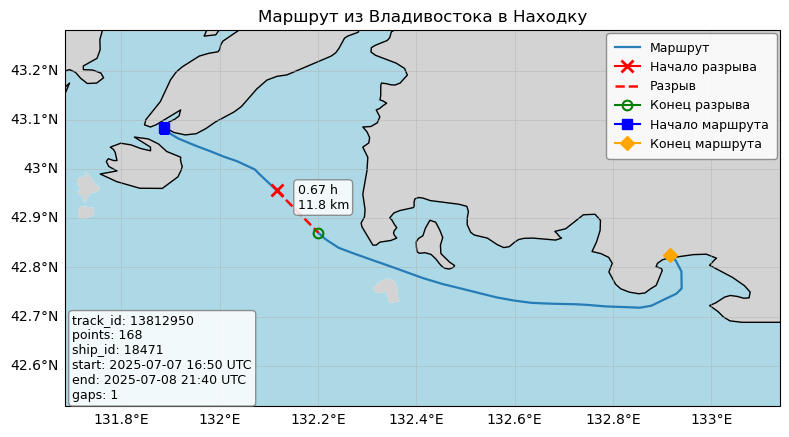

[{'i': 134,
  'dt_sec': 2397,
  'dist_m': 11813.226152001633,
  'a_lat': 42.95677947998047,
  'a_lon': 132.1158447265625,
  'b_lat': 42.87061309814453,
  'b_lon': 132.20069885253906}]

In [11]:
track_id = 13812950
plot_track_with_gaps(
    ds, track_id,
    min_gap_sec=1*3600,
    min_gap_dist_m=5_000.0,
    pad_deg=0.2,
    save_path=f"{save_path}/track_{track_id}_gaps",
    title="Маршрут из Владивостока в Находку"
)

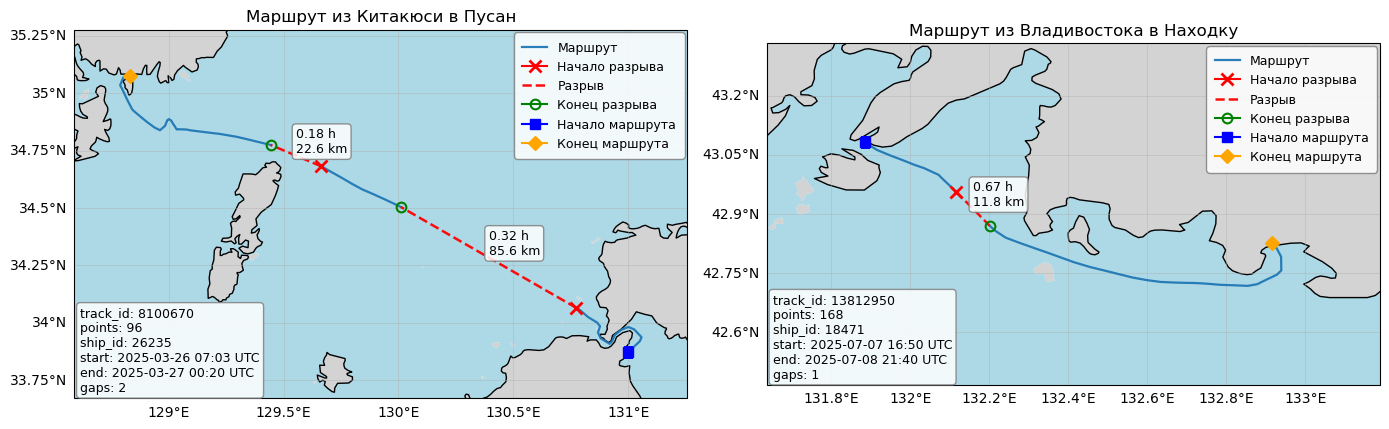

In [12]:
fig = plt.figure(figsize=(14, 8))

track_id_a = 8100670
plot_track_with_gaps(
    ds, track_id_a,
    min_gap_sec=1*3600,
    min_gap_dist_m=20_000.0,
    pad_deg=0.2,
    title="Маршрут из Китакюси в Пусан",
    ax=fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
)

track_id_b = 13812950
plot_track_with_gaps(
    ds, track_id_b,
    min_gap_sec=1*3600,
    min_gap_dist_m=5_000.0,
    pad_deg=0.25,
    title="Маршрут из Владивостока в Находку",
    ax=fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
)

fig.tight_layout()
fig.savefig(f"{save_path}/tracks_{track_id_a}_{track_id_b}_gaps.png", dpi=200,
    bbox_inches="tight",
    pad_inches=0.1)
fig.savefig(f"{save_path}/tracks_{track_id_a}_{track_id_b}_gaps.pdf", dpi=200,
    bbox_inches="tight",
    pad_inches=0.1)
plt.show()

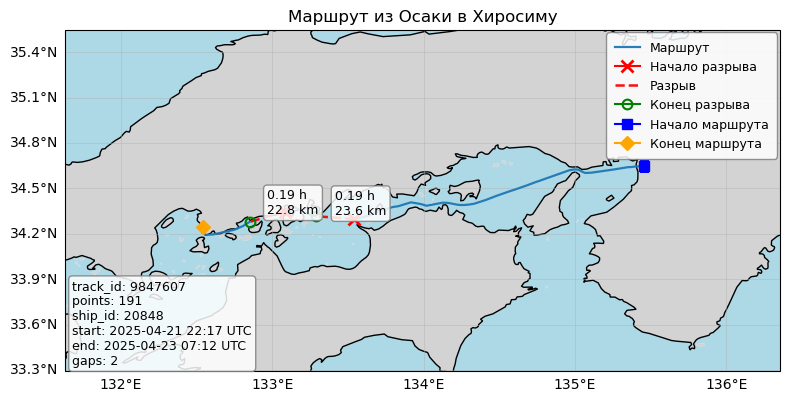

[{'i': 159,
  'dt_sec': 677,
  'dist_m': 23594.090045972443,
  'a_lat': 34.29729080200195,
  'a_lon': 133.54153442382812,
  'b_lat': 34.31599426269531,
  'b_lon': 133.28565979003906},
 {'i': 173,
  'dt_sec': 674,
  'dist_m': 22818.80294127101,
  'a_lat': 34.34611892700195,
  'a_lon': 133.08355712890625,
  'b_lat': 34.27817153930664,
  'b_lon': 132.84912109375}]

In [13]:
# track_id = 5114752
# track_id = 5690596
track_id = 9847607
plot_track_with_gaps(
    ds, track_id,
    min_gap_sec=1*3600,
    # min_gap_dist_m=50_000.0,
    # min_gap_dist_m=50_000.0,
    min_gap_dist_m=20_000.0,
    pad_deg=0.9,
    save_path=f"{save_path}/track_{track_id}_gaps",
    title="Маршрут из Осаки в Хиросиму"
)

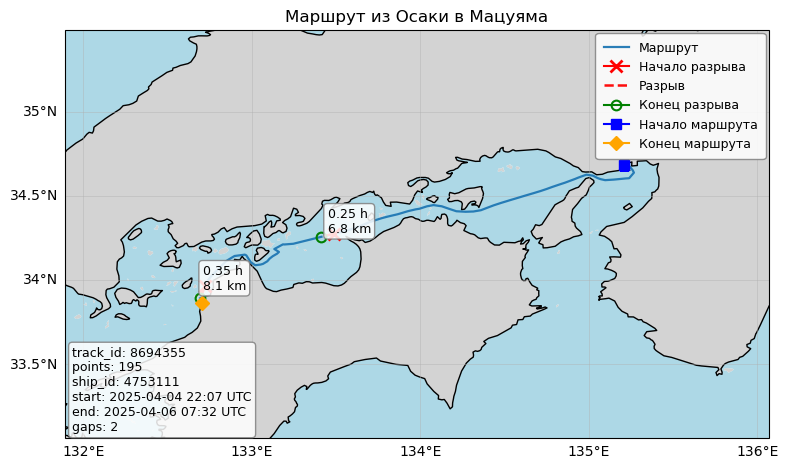

[{'i': 49,
  'dt_sec': 896,
  'dist_m': 6848.857937352847,
  'a_lat': 34.27426528930664,
  'a_lon': 133.4846954345703,
  'b_lat': 34.25706481933594,
  'b_lon': 133.4131317138672},
 {'i': 189,
  'dt_sec': 1248,
  'dist_m': 8058.488828943033,
  'a_lat': 33.96253967285156,
  'a_lon': 132.7207794189453,
  'b_lat': 33.89331817626953,
  'b_lon': 132.69491577148438}]

In [26]:
# track_id = 10203161
track_id = 8694355
plot_track_with_gaps(
    ds, track_id,
    min_gap_sec=1*3600,
    # min_gap_dist_m=20_000.0,
    min_gap_dist_m=6_500.0,
    pad_deg=0.8,
    save_path=f"{save_path}/track_{track_id}_gaps",
    title="Маршрут из Осаки в Мацуяма"
)

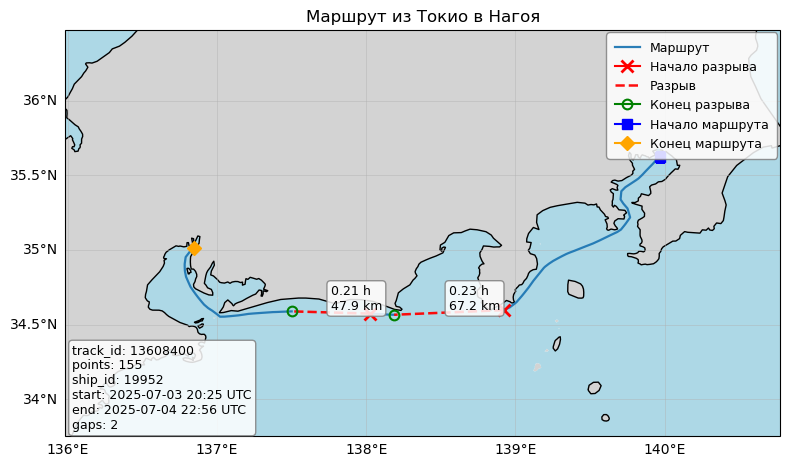

[{'i': 103,
  'dt_sec': 814,
  'dist_m': 67205.76428713478,
  'a_lat': 34.596317291259766,
  'a_lon': 138.92105102539062,
  'b_lat': 34.56528854370117,
  'b_lon': 138.18792724609375},
 {'i': 122,
  'dt_sec': 749,
  'dist_m': 47911.08657150571,
  'a_lat': 34.573211669921875,
  'a_lon': 138.02377319335938,
  'b_lat': 34.58798599243164,
  'b_lon': 137.50074768066406}]

In [24]:
track_id = 13608400
plot_track_with_gaps(
    ds, track_id,
    min_gap_sec=1*3600,
    min_gap_dist_m=15_000.0,
    pad_deg=0.8,
    save_path=f"{save_path}/track_{track_id}_gaps",
    title="Маршрут из Токио в Нагоя"
)

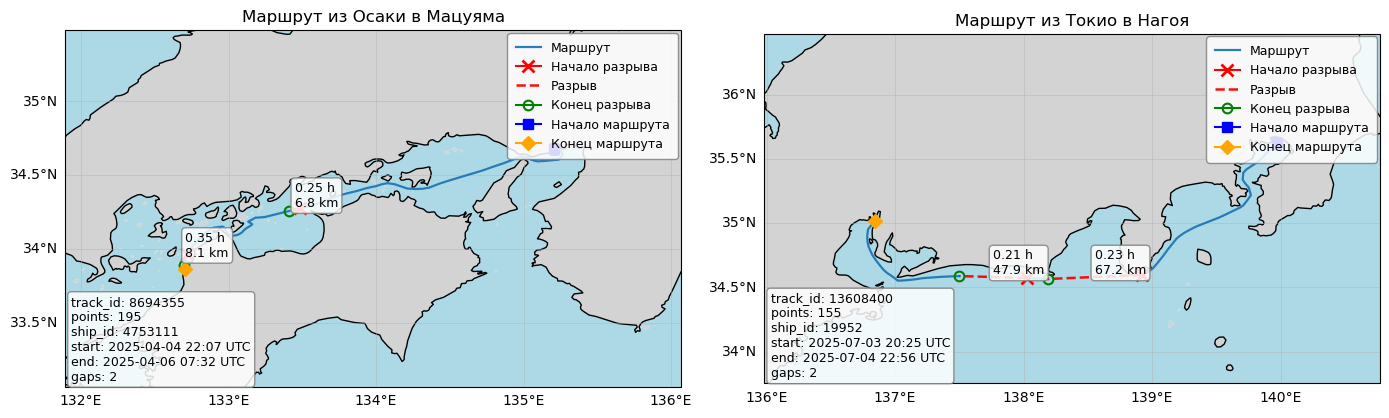

In [27]:
fig = plt.figure(figsize=(14, 8))

track_id_a = 8694355
plot_track_with_gaps(
    ds, track_id_a,
    min_gap_sec=1*3600,
    min_gap_dist_m=6_500.0,
    pad_deg=0.8,
    title="Маршрут из Осаки в Мацуяма",
    ax=fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
)

track_id_b = 13608400
plot_track_with_gaps(
    ds, track_id_b,
    min_gap_sec=1*3600,
    min_gap_dist_m=15_000.0,
    pad_deg=0.8,
    title="Маршрут из Токио в Нагоя",
    ax=fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
)

fig.tight_layout()
fig.savefig(f"{save_path}/tracks_{track_id_a}_{track_id_b}_gaps.png", dpi=200,
    bbox_inches="tight",
    pad_inches=0.1)
fig.savefig(f"{save_path}/tracks_{track_id_a}_{track_id_b}_gaps.pdf", dpi=200,
    bbox_inches="tight",
    pad_inches=0.1)
plt.show()

Build global density heatmap (days): 100%|██████████| 247/247 [06:59<00:00,  1.70s/it, points=5.88e+8]


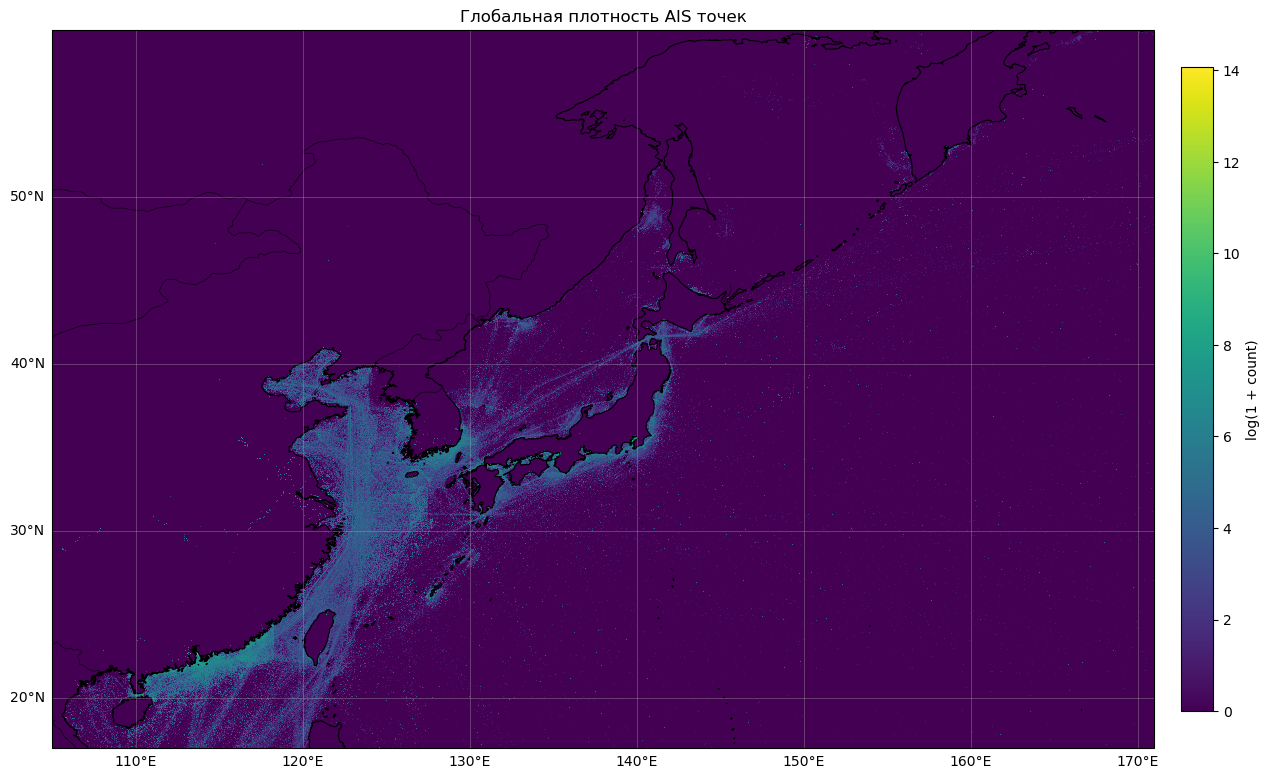

<GeoAxes: title={'center': 'Глобальная плотность AIS точек'}>

In [32]:
def list_position_day_datasets(ds, root="/positions"):
    """
    Возвращает список путей вида /positions/YYYY/MM/DD (только реальные datasets).
    Игнорирует /positions/tracks.
    """
    paths = []
    grp = ds[root]

    # ожидаем структуру /positions/YYYY/MM/DD
    for yyyy in sorted(grp.keys()):
        if yyyy == "tracks":
            continue
        g_y = grp[yyyy]
        for mm in sorted(g_y.keys()):
            g_m = g_y[mm]
            for dd in sorted(g_m.keys()):
                obj = g_m[dd]
                # day должен быть h5py.Dataset
                if hasattr(obj, "shape") and hasattr(obj, "dtype"):
                    paths.append(f"{root}/{yyyy}/{mm}/{dd}")
    return paths

def build_global_density_heatmap(
    ds,
    extent=(105.0, 171.0, 17.0, 60.0),
    bins=(1200, 900),
    root="/positions",
    dtype=np.uint64,
):
    """
    Считает heatmap плотности по всем позициям в /positions/YYYY/MM/DD.

    extent = (min_lon, max_lon, min_lat, max_lat)
    bins   = (nx, ny)
    Возвращает: heat (ny, nx) uint64
    """
    min_lon, max_lon, min_lat, max_lat = map(float, extent)
    nx, ny = map(int, bins)

    # grid
    heat = np.zeros((ny, nx), dtype=dtype)

    # список day datasets
    day_paths = list_position_day_datasets(ds, root=root)
    pbar = tqdm(day_paths, desc="Build global density heatmap (days)")

    # предрасчёт для индексации
    inv_lon = nx / (max_lon - min_lon)
    inv_lat = ny / (max_lat - min_lat)

    total_points_seen = 0

    for path in pbar:
        dset = ds[path]
        n = int(dset.shape[0])
        if n == 0:
            continue

        # читаем lat/lon (векторно)
        lat = dset["lat"][...].astype(np.float64, copy=False)
        lon = dset["lon"][...].astype(np.float64, copy=False)

        # быстрый bbox фильтр
        m = (lon >= min_lon) & (lon < max_lon) & (lat >= min_lat) & (lat < max_lat)
        if not np.any(m):
            continue

        lat = lat[m]
        lon = lon[m]
        k = lat.size
        total_points_seen += int(k)

        # индексы бинов
        ix = ((lon - min_lon) * inv_lon).astype(np.int64)
        iy = ((lat - min_lat) * inv_lat).astype(np.int64)

        # защита от края (из-за float)
        np.clip(ix, 0, nx - 1, out=ix)
        np.clip(iy, 0, ny - 1, out=iy)

        # плоский индекс и накопление
        flat = iy * nx + ix
        binc = np.bincount(flat, minlength=nx * ny)

        heat += binc.reshape(ny, nx).astype(dtype, copy=False)

        pbar.set_postfix(points=total_points_seen)

    return heat

def plot_global_density_heatmap(
    heat,
    extent=(105.0, 171.0, 17.0, 60.0),
    ax=None,
    title="Плотность AIS-точек (global heatmap)",
    use_log=True,
):
    min_lon, max_lon, min_lat, max_lat = map(float, extent)

    if ax is None:
        fig = plt.figure(figsize=(14, 8))
        ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
        local_ax = True
    else:
        local_ax = False

    ax.set_extent((min_lon, max_lon, min_lat, max_lat), crs=ccrs.PlateCarree())

    # подложка: heatmap
    data = heat.astype(np.float64)
    if use_log:
        data = np.log1p(data)

    im = ax.imshow(
        data,
        origin="lower",
        extent=(min_lon, max_lon, min_lat, max_lat),
        transform=ccrs.PlateCarree(),
        interpolation="nearest",
    )

    # (опционально) оверлей географии — обычно полезно
    ax.coastlines(resolution="10m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.8)

    gl = ax.gridlines(draw_labels=True, alpha=0.4, linewidth=0.6)
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(title)

    cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
    cbar.set_label("log(1 + count)" if use_log else "count")

    if local_ax:
        fig.tight_layout()
        plt.show()

    return ax

extent = (105.0, 171.0, 17.0, 60.0)
bins = (1200*8, 900*8)

heat_global = build_global_density_heatmap(ds, extent=extent, bins=bins)

plot_global_density_heatmap(heat_global, extent=extent, title="Глобальная плотность AIS точек", use_log=True)


In [46]:
def crop_heatmap(heat, global_extent, window_extent):
    """
    heat: (ny, nx)
    global_extent: (min_lon, max_lon, min_lat, max_lat) — как при построении heat
    window_extent: (min_lon, max_lon, min_lat, max_lat) — окно трека

    Возвращает: heat_crop, crop_extent (в lon/lat), slices (yslice, xslice)
    """
    g_min_lon, g_max_lon, g_min_lat, g_max_lat = map(float, global_extent)
    w_min_lon, w_max_lon, w_min_lat, w_max_lat = map(float, window_extent)

    ny, nx = heat.shape

    # нормируем window -> индексы
    x0 = int(np.floor((w_min_lon - g_min_lon) / (g_max_lon - g_min_lon) * nx))
    x1 = int(np.ceil ((w_max_lon - g_min_lon) / (g_max_lon - g_min_lon) * nx))
    y0 = int(np.floor((w_min_lat - g_min_lat) / (g_max_lat - g_min_lat) * ny))
    y1 = int(np.ceil ((w_max_lat - g_min_lat) / (g_max_lat - g_min_lat) * ny))

    # clip
    x0 = max(0, min(nx, x0)); x1 = max(0, min(nx, x1))
    y0 = max(0, min(ny, y0)); y1 = max(0, min(ny, y1))

    if x1 <= x0 or y1 <= y0:
        # пустое окно
        return heat[0:0, 0:0], (w_min_lon, w_max_lon, w_min_lat, w_max_lat), (slice(0,0), slice(0,0))

    heat_crop = heat[y0:y1, x0:x1]

    # точный extent кропа по пиксельной сетке (чтобы imshow совпадал)
    c_min_lon = g_min_lon + (x0 / nx) * (g_max_lon - g_min_lon)
    c_max_lon = g_min_lon + (x1 / nx) * (g_max_lon - g_min_lon)
    c_min_lat = g_min_lat + (y0 / ny) * (g_max_lat - g_min_lat)
    c_max_lat = g_min_lat + (y1 / ny) * (g_max_lat - g_min_lat)

    return heat_crop, (c_min_lon, c_max_lon, c_min_lat, c_max_lat), (slice(y0,y1), slice(x0,x1))

def plot_track_with_gaps_on_density(
    ds,
    heat_global,
    global_extent=(105.0, 171.0, 17.0, 60.0),
    track_id: int = 0,
    min_gap_sec=3600,
    min_gap_dist_m=20000.0,
    pad_deg=0.25,
    title="Маршрут с разрывами (на плотности)",
    ax=None,
    use_log=True,
):
    pts = get_track_points(ds, int(track_id))

    lat = pts["lat"].astype(np.float64)
    lon = pts["lon"].astype(np.float64)
    ts  = pts["timestamp"].astype(np.int64)

    gaps = compute_track_gaps(pts, min_gap_sec=min_gap_sec, min_gap_dist_m=min_gap_dist_m)

    # Окно трека
    min_lon, max_lon = float(lon.min()), float(lon.max())
    min_lat, max_lat = float(lat.min()), float(lat.max())
    win_extent = (min_lon - pad_deg, max_lon + pad_deg, min_lat - pad_deg, max_lat + pad_deg)

    # Кроп плотности под окно
    heat_crop, crop_extent, _ = crop_heatmap(heat_global, global_extent, win_extent)

    if ax is None:
        fig = plt.figure(figsize=(8, 5))
        ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
        local_ax = True
    else:
        local_ax = False

    ax.set_extent(win_extent, crs=ccrs.PlateCarree())

    # Heatmap плотности
    data = heat_crop.astype(np.float64)
    if use_log:
        data = np.log1p(data)

    im = ax.imshow(
        data,
        origin="lower",
        extent=crop_extent,
        transform=ccrs.PlateCarree(),
        interpolation="nearest",
        alpha=0.95,
        zorder=0,
    )

    # География
    ax.coastlines(resolution="10m", linewidth=0.8, zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.8, zorder=3)

    gl = ax.gridlines(draw_labels=True, alpha=0.5, linewidth=0.6)
    gl.top_labels = False
    gl.right_labels = False

    # Маршрут
    cut = sorted(set(g["i"] for g in gaps))
    start_idx = 0
    for i in cut:
        end_idx = i + 1
        ax.plot(
            lon[start_idx:end_idx], lat[start_idx:end_idx],
            color="tab:orange",
            linewidth=1.8, alpha=0.95,
            transform=ccrs.PlateCarree(),
            label="Маршрут" if start_idx == 0 else None,
            zorder=5,
        )
        start_idx = end_idx

    ax.plot(
        lon[start_idx:], lat[start_idx:],
        color="tab:orange",
        linewidth=1.8, alpha=0.95,
        transform=ccrs.PlateCarree(),
        label=None,
        zorder=5,
    )

    # Разрывы
    first_gap = True
    for g in gaps:
        ax.plot(
            g["a_lon"], g["a_lat"],
            marker="x", markersize=9,
            color="red",
            markeredgewidth=2.0,
            transform=ccrs.PlateCarree(),
            label="Начало разрыва" if first_gap else None,
            zorder=6,
        )

        ax.plot(
            [g["a_lon"], g["b_lon"]], [g["a_lat"], g["b_lat"]],
            linestyle="--", linewidth=2.0, alpha=0.95, color="red",
            transform=ccrs.PlateCarree(),
            label="Разрыв" if first_gap else None,
            zorder=6,
        )

        ax.plot(
            g["b_lon"], g["b_lat"],
            marker="o", markersize=7,
            color="green",
            markeredgewidth=1.5, markerfacecolor="none",
            transform=ccrs.PlateCarree(),
            label="Конец разрыва" if first_gap else None,
            zorder=6,
        )

        mid_lon = 0.5 * (g["a_lon"] + g["b_lon"])
        mid_lat = 0.5 * (g["a_lat"] + g["b_lat"])
        dt_h = g["dt_sec"] / 3600.0
        dist_km = g["dist_m"] / 1000.0

        ax.text(
            mid_lon, mid_lat, f"{dt_h:.2f} h\n{dist_km:.1f} km",
            transform=ccrs.PlateCarree(),
            fontsize=9, ha="left", va="bottom",
            bbox=dict(boxstyle="round", alpha=0.85, color="white", ec="gray"),
            zorder=7,
        )

        first_gap = False

    # Старт/финиш
    ax.plot(lon[0], lat[0], marker="s", markersize=7, color="blue",
            transform=ccrs.PlateCarree(), label="Начало маршрута", zorder=6)
    ax.plot(lon[-1], lat[-1], marker="D", markersize=7, color="orange",
            transform=ccrs.PlateCarree(), label="Конец маршрута", zorder=6)

    # Тнфо-блок
    ship_id = int(pts["ship_id"][0]) if "ship_id" in pts.dtype.names else None
    n = len(pts)
    t0 = datetime.fromtimestamp(int(ts[0]), tz=timezone.utc)
    t1 = datetime.fromtimestamp(int(ts[-1]), tz=timezone.utc)

    info = (
        f"track_id: {track_id}\n"
        f"points: {n}\n"
        f"ship_id: {ship_id}\n"
        f"start: {t0:%Y-%m-%d %H:%M} UTC\n"
        f"end: {t1:%Y-%m-%d %H:%M} UTC\n"
        f"gaps: {len(gaps)}"
    )
    ax.text(
        0.01, 0.01, info, transform=ax.transAxes,
        ha="left", va="bottom", fontsize=9,
        bbox=dict(boxstyle="round", alpha=0.85, color="white", ec="gray"),
        zorder=8,
    )

    ax.set_title(title)

    leg = ax.legend(loc="upper right", fontsize=9, frameon=True, fancybox=True)
    frame = leg.get_frame()
    frame.set_facecolor("white")
    frame.set_edgecolor("gray")
    frame.set_alpha(0.85)
    frame.set_boxstyle("round")
    leg.set_zorder(20)

    if local_ax:
        cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
        cbar.set_label("log(1 + count)" if use_log else "count")

        fig.tight_layout()
        plt.show()

    return gaps, im


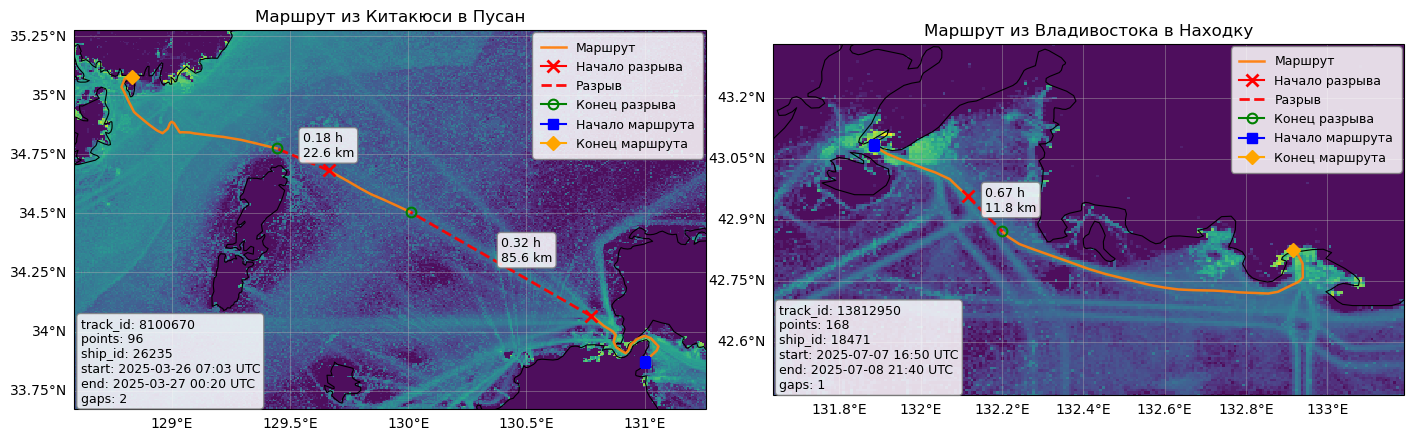

In [48]:
fig = plt.figure(figsize=(14, 8))

track_id_a = 8100670
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
plot_track_with_gaps_on_density(
    ds,
    heat_global,
    global_extent=(105.0, 171.0, 17.0, 60.0),
    track_id=track_id_a,
    min_gap_sec=1*3600,
    min_gap_dist_m=20_000.0,
    pad_deg=0.2,
    title="Маршрут из Китакюси в Пусан",
    ax=ax1,
)

track_id_b = 13812950
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
plot_track_with_gaps_on_density(
    ds,
    heat_global,
    global_extent=(105.0, 171.0, 17.0, 60.0),
    track_id=track_id_b,
    min_gap_sec=1*3600,
    min_gap_dist_m=5_000.0,
    pad_deg=0.25,
    title="Маршрут из Владивостока в Находку",
    ax=ax2,
)

fig.tight_layout(pad=0.2)
fig.canvas.draw()
fig.savefig(f"{save_path}/tracks_density_{track_id_a}_{track_id_b}.png", dpi=200, bbox_inches="tight", pad_inches=0.1)
fig.savefig(f"{save_path}/tracks_density_{track_id_a}_{track_id_b}.pdf", dpi=200, bbox_inches="tight", pad_inches=0.1)
plt.show()


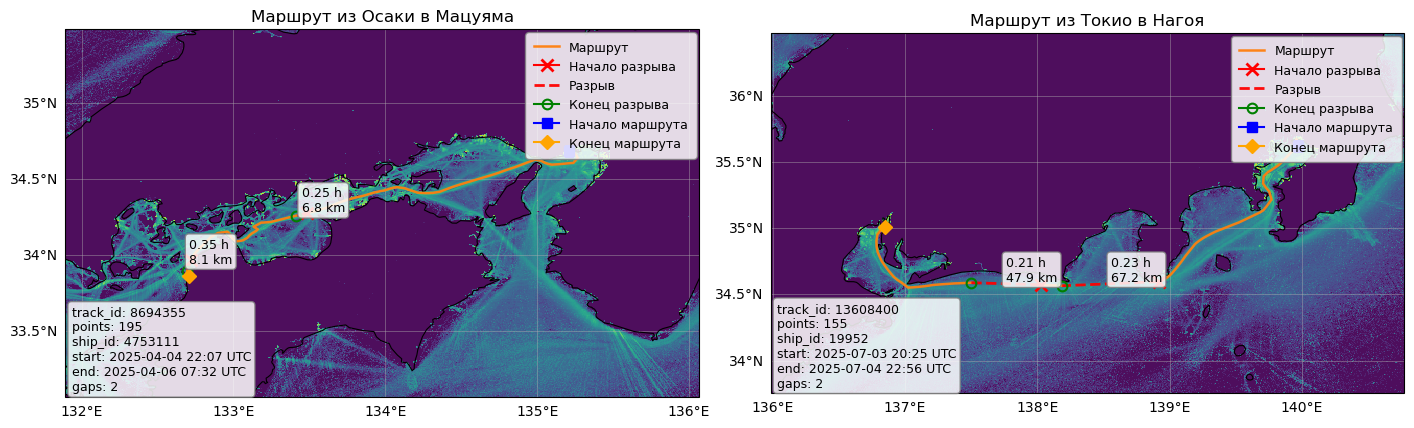

In [47]:
fig = plt.figure(figsize=(14, 8))

track_id_a = 8694355
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
plot_track_with_gaps_on_density(
    ds,
    heat_global,
    global_extent=(105.0, 171.0, 17.0, 60.0),
    track_id=track_id_a,
    min_gap_sec=1*3600,
    min_gap_dist_m=6_500.0,
    pad_deg=0.8,
    title="Маршрут из Осаки в Мацуяма",
    ax=ax1,
)

track_id_b = 13608400
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
plot_track_with_gaps_on_density(
    ds,
    heat_global,
    global_extent=(105.0, 171.0, 17.0, 60.0),
    track_id=track_id_b,
    min_gap_sec=1*3600,
    min_gap_dist_m=15_000.0,
    pad_deg=0.8,
    title="Маршрут из Токио в Нагоя",
    ax=ax2,
)

fig.tight_layout(pad=0.2)
fig.canvas.draw()
fig.savefig(f"{save_path}/tracks_density_{track_id_a}_{track_id_b}.png", dpi=200, bbox_inches="tight", pad_inches=0.1)
fig.savefig(f"{save_path}/tracks_density_{track_id_a}_{track_id_b}.pdf", dpi=200, bbox_inches="tight", pad_inches=0.1)
plt.show()


In [150]:
def get_ship_tracks(ds, ship_id: int, chunk_rows=2_000_000, min_points=0):
    """
    Сканируем ds["tracks"] чанками и собираем все треки для ship_id
    Возвращает DataFrame: track_id, start_ts, end_ts, points_count
    """
    tr = ds["tracks"]
    n = tr.shape[0]
    out = []

    pbar = tqdm(range(1000000, n, chunk_rows), total=(n + chunk_rows - 1)//chunk_rows, desc=f"Scan tracks for ship_id={ship_id}")
    for i0 in pbar:
        i1 = min(n, i0 + chunk_rows)
        chunk = tr[i0:i1]

        m = chunk["ship_id"] == int(ship_id)
        if not np.any(m):
            continue

        sub = chunk[m]
        if min_points > 0:
            sub = sub[sub["points_count"] >= int(min_points)]
            if sub.shape[0] == 0:
                continue

        out.append(np.stack([
            sub["track_id"].astype(np.int64),
            sub["start_timestamp"].astype(np.int64),
            sub["end_timestamp"].astype(np.int64),
            sub["points_count"].astype(np.int32),
        ], axis=1))

    if not out:
        return pd.DataFrame(columns=["track_id","start_ts","end_ts","points_count"])

    arr = np.concatenate(out, axis=0)
    df = pd.DataFrame(arr, columns=["track_id","start_ts","end_ts","points_count"])
    df.sort_values(["start_ts","track_id"], inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df

def get_track_latlon(ds, track_id: int):
    """Достаём точки трека через уже существующий get_track_points()."""
    pts = get_track_points(ds, int(track_id))
    lat = pts["lat"].astype(np.float64)
    lon = pts["lon"].astype(np.float64)
    ts  = pts["timestamp"].astype(np.int64)
    return lat, lon, ts

def plot_three_tracks_one_ship(
    ds,
    ship_id: int,
    track_ids=None,
    chunk_rows=2_000_000,
    min_points=0,
    pad_deg=0.25,
    title=None,
):
    """
    Рисует 3 маршрута одного судна на одной карте разными цветами.
    Если track_ids не задан -> берём 3 трека судна по start_ts (самые ранние).
    """

    # 1) выбрать треки
    if track_ids is None:
        df = get_ship_tracks(ds, ship_id, chunk_rows=chunk_rows, min_points=min_points)
        if len(df) < 3:
            raise ValueError(f"Found only {len(df)} tracks for ship_id={ship_id}, need 3.")
        pick = df.head(3).copy()
        track_ids = pick["track_id"].astype(int).tolist()
        meta = pick
    else:
        track_ids = [int(x) for x in track_ids]
        # мета (опционально) — попробуем вытащить из таблицы tracks
        meta = None

    # 2) читаем точки, собираем общий extent
    tracks = []
    min_lon = +1e9; max_lon = -1e9
    min_lat = +1e9; max_lat = -1e9

    for tid in track_ids:
        lat, lon, ts = get_track_latlon(ds, tid)
        tracks.append((tid, lat, lon, ts))
        min_lon = min(min_lon, float(lon.min()))
        max_lon = max(max_lon, float(lon.max()))
        min_lat = min(min_lat, float(lat.min()))
        max_lat = max(max_lat, float(lat.max()))

    extent = (min_lon - pad_deg, max_lon + pad_deg, min_lat - pad_deg, max_lat + pad_deg)

    # 3) рисуем
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    set_map_style(ax)

    colors = ["tab:blue", "tab:orange", "tab:green"]

    for j, (tid, lat, lon, ts) in enumerate(tracks):
        c = colors[j % len(colors)]

        t0 = datetime.fromtimestamp(int(ts[0]), tz=timezone.utc)
        t1 = datetime.fromtimestamp(int(ts[-1]), tz=timezone.utc)

        ax.plot(
            lon, lat,
            color=c, linewidth=2.0, alpha=0.95,
            transform=ccrs.PlateCarree(),
            label=f"Track {j+1}: {tid} ({t0:%Y-%m-%d} -> {t1:%Y-%m-%d})",
            zorder=5,
        )

        # маркеры начала/конца
        ax.plot(lon[0],  lat[0],  marker="s", markersize=6, color=c, transform=ccrs.PlateCarree(), zorder=6)
        ax.plot(lon[-1], lat[-1], marker="D", markersize=6, color=c, transform=ccrs.PlateCarree(), zorder=6)

        # подпись номера на старте (чтобы “последовательно” читалось)
        # ax.text(
        #     lon[0], lat[0], f"{j+1}",
        #     transform=ccrs.PlateCarree(),
        #     fontsize=10, fontweight="bold",
        #     ha="left", va="bottom",
        #     bbox=dict(boxstyle="round", alpha=0.85, color="white", ec="gray"),
        #     zorder=7,
        # )

    # 4) заголовок + легенда
    if title is None:
        title = f"3 маршрута судна {ship_id} (последовательно)"
    ax.set_title(title)

    leg = ax.legend(loc="lower right", fontsize=9, frameon=True, fancybox=True)
    leg.set_zorder(20)
    frame = leg.get_frame()
    frame.set_facecolor("white")
    frame.set_edgecolor("gray")
    frame.set_alpha(0.85)
    frame.set_boxstyle("round")

    fig.tight_layout()
    # plt.show()

    return track_ids

Scan tracks for ship_id=20656: 100%|██████████| 6/6 [00:01<00:00,  3.45it/s]


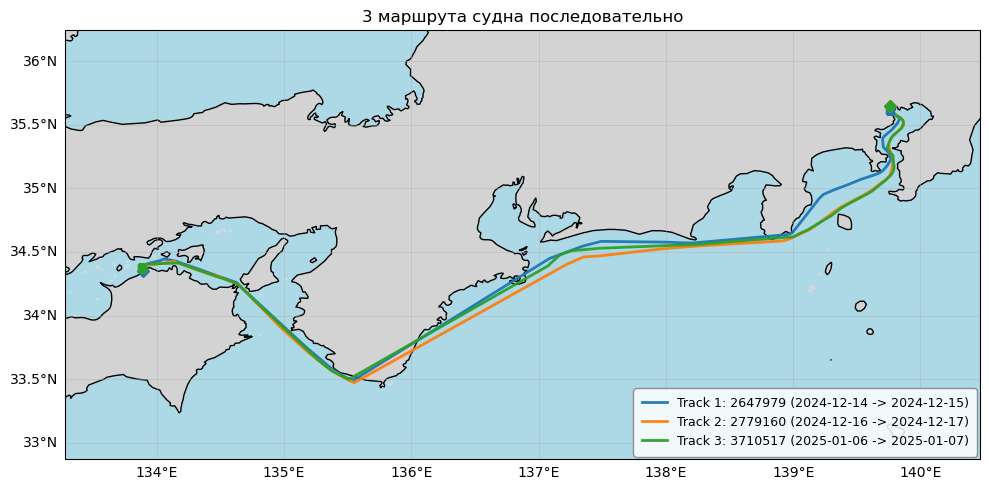

In [151]:
ship_id = 20656
track_ids = plot_three_tracks_one_ship(ds, ship_id, min_points=200, pad_deg=0.6, title="3 маршрута судна последовательно")

plt.savefig(f"{save_path}/ship_3tracks_{ship_id}.png", dpi=200, bbox_inches="tight", pad_inches=0.1)
plt.savefig(f"{save_path}/ship_3tracks_{ship_id}.pdf", dpi=200, bbox_inches="tight", pad_inches=0.1)

plt.show()


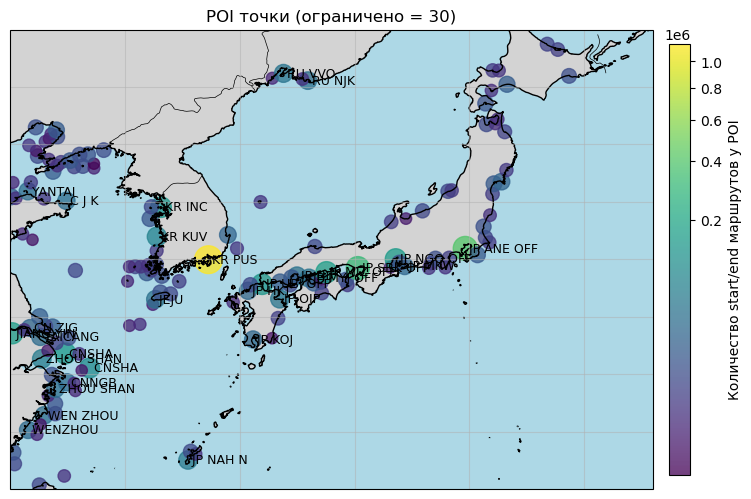

In [189]:
pois = poi["pois"]

extent = (120.0, 148.0, 25.0, 45.0)

top_label_len = 10          # обрезка подписи
min_count_to_label = 200    # подписи только для достаточно крупных POI
max_labels = 30             # верхний лимит подписей (по убыванию count_total)
gamma = 0.3                # нелинейность для цвета и размеров

lats = np.array([p["center_lat"] for p in pois], dtype=np.float64)
lons = np.array([p["center_lon"] for p in pois], dtype=np.float64)
counts = np.array([p["count_total"] for p in pois], dtype=np.float64)

labels = []
for p in pois:
    td = p.get("top_destinations") or []
    name = td[0]["name"] if td else ""
    name = str(name).strip()
    if len(name) > top_label_len:
        name = name[:top_label_len - 1] + "…"
    labels.append(name)

# фильтр по extent (чтобы не рисовать и не подписывать вне области)
min_lon, max_lon, min_lat, max_lat = map(float, extent)
in_view = (lons >= min_lon) & (lons <= max_lon) & (lats >= min_lat) & (lats <= max_lat)

lats_v = lats[in_view]
lons_v = lons[in_view]
counts_v = counts[in_view]
labels_v = [lab for lab, ok in zip(labels, in_view) if ok]

# размеры точек: нелинейно от count (нормируем на max внутри видимой области)
cmax = float(counts_v.max()) if counts_v.size else 1.0
cmax = max(cmax, 1.0)
sizes_v = 20.0 + 380.0 * (counts_v / cmax) ** gamma

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

ax.coastlines(resolution="10m")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.gridlines(draw_labels=False, alpha=0.5)

# цвет по count_total (только видимая область)
vmin = float(counts_v.min()) if counts_v.size else 1.0
vmin = max(1.0, vmin)
norm = PowerNorm(gamma=gamma, vmin=vmin, vmax=cmax)

sc = ax.scatter(
    lons_v, lats_v,
    s=sizes_v,
    c=counts_v,
    norm=norm,
    alpha=0.75,
    transform=ccrs.PlateCarree(),
    clip_on=True,
)

cbar = plt.colorbar(sc, ax=ax, orientation="vertical", pad=0.02, shrink=0.70)
cbar.set_label("Количество start/end маршрутов у POI")

# подписи: только для видимых точек
order = np.argsort(-counts_v)
printed = 0
for i in order:
    if printed >= max_labels:
        break
    if counts_v[i] < min_count_to_label:
        break
    if not labels_v[i]:
        continue

    ax.text(
        lons_v[i], lats_v[i],
        " " + labels_v[i],
        fontsize=9,
        transform=ccrs.PlateCarree(),
        ha="left", va="center",
        clip_on=True,
    )
    printed += 1

ax.set_title(f"POI точки (ограничено = {printed})", fontsize=12)

plt.savefig(f"{save_path}/poi_full.png", dpi=200, bbox_inches="tight", pad_inches=0.1)
plt.savefig(f"{save_path}/poi_full.pdf", dpi=200, bbox_inches="tight", pad_inches=0.1)

plt.show()


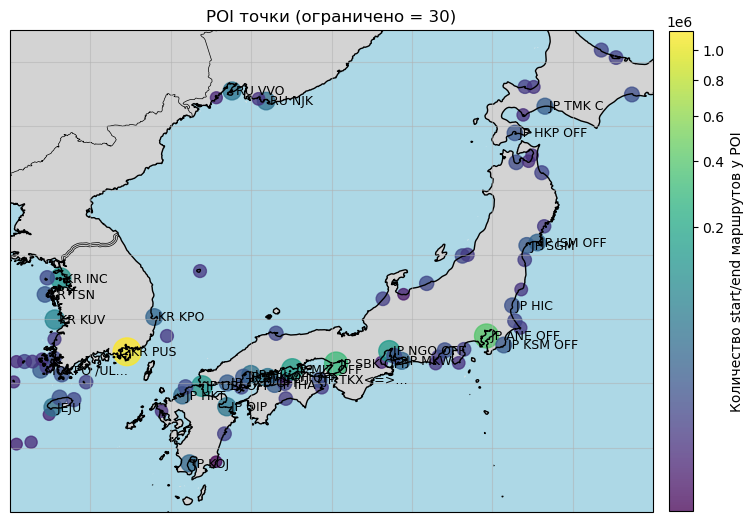

In [197]:
pois = poi["pois"]

extent = (125.0, 145.0, 30.0, 45.0)

top_label_len = 10          # обрезка подписи
min_count_to_label = 200    # подписи только для достаточно крупных POI
max_labels = 30             # верхний лимит подписей (по убыванию count_total)
gamma = 0.3                # нелинейность для цвета и размеров

lats = np.array([p["center_lat"] for p in pois], dtype=np.float64)
lons = np.array([p["center_lon"] for p in pois], dtype=np.float64)
counts = np.array([p["count_total"] for p in pois], dtype=np.float64)

labels = []
for p in pois:
    td = p.get("top_destinations") or []
    name = td[0]["name"] if td else ""
    name = str(name).strip()
    if len(name) > top_label_len:
        name = name[:top_label_len - 1] + "…"
    labels.append(name)

# фильтр по extent (чтобы не рисовать и не подписывать вне области)
min_lon, max_lon, min_lat, max_lat = map(float, extent)
in_view = (lons >= min_lon) & (lons <= max_lon) & (lats >= min_lat) & (lats <= max_lat)

lats_v = lats[in_view]
lons_v = lons[in_view]
counts_v = counts[in_view]
labels_v = [lab for lab, ok in zip(labels, in_view) if ok]

# размеры точек: нелинейно от count (нормируем на max внутри видимой области)
cmax = float(counts_v.max()) if counts_v.size else 1.0
cmax = max(cmax, 1.0)
sizes_v = 20.0 + 380.0 * (counts_v / cmax) ** gamma

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

ax.coastlines(resolution="10m")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.gridlines(draw_labels=False, alpha=0.5)

# цвет по count_total (только видимая область)
vmin = float(counts_v.min()) if counts_v.size else 1.0
vmin = max(1.0, vmin)
norm = PowerNorm(gamma=gamma, vmin=vmin, vmax=cmax)

sc = ax.scatter(
    lons_v, lats_v,
    s=sizes_v,
    c=counts_v,
    norm=norm,
    alpha=0.75,
    transform=ccrs.PlateCarree(),
    clip_on=True,
)

cbar = plt.colorbar(sc, ax=ax, orientation="vertical", pad=0.02, shrink=0.78)
cbar.set_label("Количество start/end маршрутов у POI")

# подписи: только для видимых точек
order = np.argsort(-counts_v)
printed = 0
for i in order:
    if printed >= max_labels:
        break
    if counts_v[i] < min_count_to_label:
        break
    if not labels_v[i]:
        continue

    ax.text(
        lons_v[i], lats_v[i],
        " " + labels_v[i],
        fontsize=9,
        transform=ccrs.PlateCarree(),
        ha="left", va="center",
        clip_on=True,
    )
    printed += 1

ax.set_title(f"POI точки (ограничено = {printed})", fontsize=12)

plt.savefig(f"{save_path}/poi_full_crop.png", dpi=200, bbox_inches="tight", pad_inches=0.1)
plt.savefig(f"{save_path}/poi_full_crop.pdf", dpi=200, bbox_inches="tight", pad_inches=0.1)

plt.show()


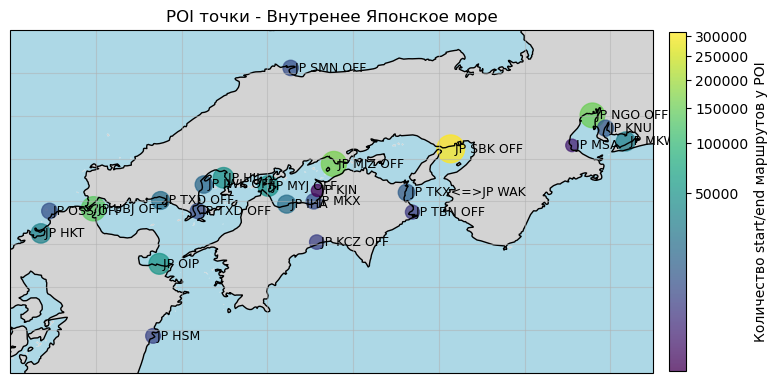

In [194]:
pois = poi["pois"]

extent = (130.0, 137.5, 32.0, 36.0)

top_label_len = 22          # обрезка подписи
min_count_to_label = 200    # подписи только для достаточно крупных POI
max_labels = 60             # верхний лимит подписей (по убыванию count_total)
gamma = 0.35                # нелинейность для цвета и размеров

lats = np.array([p["center_lat"] for p in pois], dtype=np.float64)
lons = np.array([p["center_lon"] for p in pois], dtype=np.float64)
counts = np.array([p["count_total"] for p in pois], dtype=np.float64)

labels = []
for p in pois:
    td = p.get("top_destinations") or []
    name = td[0]["name"] if td else ""
    name = str(name).strip()
    if len(name) > top_label_len:
        name = name[:top_label_len - 1] + "…"
    labels.append(name)

# фильтр по extent (чтобы не рисовать и не подписывать вне области)
min_lon, max_lon, min_lat, max_lat = map(float, extent)
in_view = (lons >= min_lon) & (lons <= max_lon) & (lats >= min_lat) & (lats <= max_lat)

lats_v = lats[in_view]
lons_v = lons[in_view]
counts_v = counts[in_view]
labels_v = [lab for lab, ok in zip(labels, in_view) if ok]

# размеры точек: нелинейно от count (нормируем на max внутри видимой области)
cmax = float(counts_v.max()) if counts_v.size else 1.0
cmax = max(cmax, 1.0)
sizes_v = 20.0 + 380.0 * (counts_v / cmax) ** gamma

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

ax.coastlines(resolution="10m")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.gridlines(draw_labels=False, alpha=0.5)

# цвет по count_total (только видимая область)
vmin = float(counts_v.min()) if counts_v.size else 1.0
vmin = max(1.0, vmin)
norm = PowerNorm(gamma=gamma, vmin=vmin, vmax=cmax)

sc = ax.scatter(
    lons_v, lats_v,
    s=sizes_v,
    c=counts_v,
    norm=norm,
    alpha=0.75,
    transform=ccrs.PlateCarree(),
    clip_on=True,
)

cbar = plt.colorbar(sc, ax=ax, orientation="vertical", pad=0.02, shrink=0.55)
cbar.set_label("Количество start/end маршрутов у POI")

# подписи: только для видимых точек
order = np.argsort(-counts_v)
printed = 0
for i in order:
    if printed >= max_labels:
        break
    if counts_v[i] < min_count_to_label:
        break
    if not labels_v[i]:
        continue

    ax.text(
        lons_v[i], lats_v[i],
        " " + labels_v[i],
        fontsize=9,
        transform=ccrs.PlateCarree(),
        ha="left", va="center",
        clip_on=True,
    )
    printed += 1

ax.set_title(f"POI точки - Внутренее Японское море", fontsize=12)

plt.savefig(f"{save_path}/poi_japan_sea.png", dpi=200, bbox_inches="tight", pad_inches=0.1)
plt.savefig(f"{save_path}/poi_japan_sea.pdf", dpi=200, bbox_inches="tight", pad_inches=0.1)

plt.show()


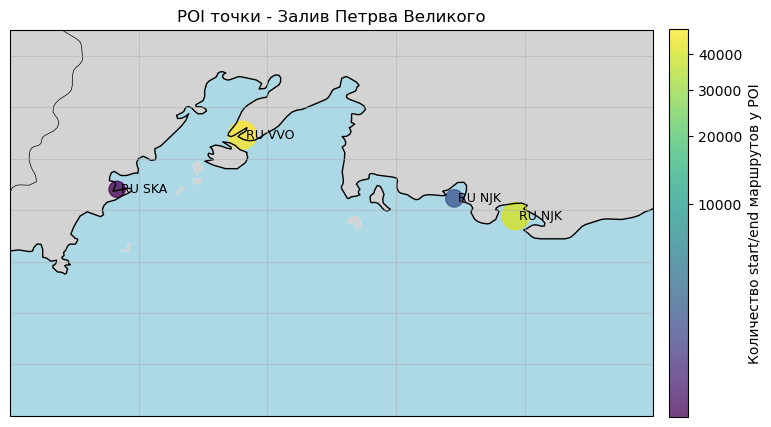

In [193]:
pois = poi["pois"]

extent = (131.0, 133.5, 42.0, 43.5)

top_label_len = 22          # обрезка подписи
min_count_to_label = 200    # подписи только для достаточно крупных POI
max_labels = 60             # верхний лимит подписей (по убыванию count_total)
gamma = 0.35                # нелинейность для цвета и размеров

lats = np.array([p["center_lat"] for p in pois], dtype=np.float64)
lons = np.array([p["center_lon"] for p in pois], dtype=np.float64)
counts = np.array([p["count_total"] for p in pois], dtype=np.float64)

labels = []
for p in pois:
    td = p.get("top_destinations") or []
    name = td[0]["name"] if td else ""
    name = str(name).strip()
    if len(name) > top_label_len:
        name = name[:top_label_len - 1] + "…"
    labels.append(name)

# фильтр по extent (чтобы не рисовать и не подписывать вне области)
min_lon, max_lon, min_lat, max_lat = map(float, extent)
in_view = (lons >= min_lon) & (lons <= max_lon) & (lats >= min_lat) & (lats <= max_lat)

lats_v = lats[in_view]
lons_v = lons[in_view]
counts_v = counts[in_view]
labels_v = [lab for lab, ok in zip(labels, in_view) if ok]

# размеры точек: нелинейно от count (нормируем на max внутри видимой области)
cmax = float(counts_v.max()) if counts_v.size else 1.0
cmax = max(cmax, 1.0)
sizes_v = 20.0 + 380.0 * (counts_v / cmax) ** gamma

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

ax.coastlines(resolution="10m")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.gridlines(draw_labels=False, alpha=0.5)

# цвет по count_total (только видимая область)
vmin = float(counts_v.min()) if counts_v.size else 1.0
vmin = max(1.0, vmin)
norm = PowerNorm(gamma=gamma, vmin=vmin, vmax=cmax)

sc = ax.scatter(
    lons_v, lats_v,
    s=sizes_v,
    c=counts_v,
    norm=norm,
    alpha=0.75,
    transform=ccrs.PlateCarree(),
    clip_on=True,
)

cbar = plt.colorbar(sc, ax=ax, orientation="vertical", pad=0.02, shrink=0.63)
cbar.set_label("Количество start/end маршрутов у POI")

# подписи: только для видимых точек
order = np.argsort(-counts_v)
printed = 0
for i in order:
    if printed >= max_labels:
        break
    if counts_v[i] < min_count_to_label:
        break
    if not labels_v[i]:
        continue

    ax.text(
        lons_v[i], lats_v[i],
        " " + labels_v[i],
        fontsize=9,
        transform=ccrs.PlateCarree(),
        ha="left", va="center",
        clip_on=True,
    )
    printed += 1

ax.set_title(f"POI точки - Залив Петрва Великого", fontsize=12)

plt.savefig(f"{save_path}/poi_zaliv_petra_velikogo.png", dpi=200, bbox_inches="tight", pad_inches=0.1)
plt.savefig(f"{save_path}/poi_zaliv_petra_velikogo.pdf", dpi=200, bbox_inches="tight", pad_inches=0.1)

plt.show()


In [201]:
csv_path = "/Volumes/SSD/mark/Documents/Projects/marinetraffic-collector/research/checkpoints/20260113_030202_bs16_ch4/history.csv"

dfm = pd.read_csv(csv_path)

dfm["epoch"] = pd.to_numeric(dfm["epoch"], errors="coerce").astype("Int64")
dfm = dfm.dropna(subset=["epoch"]).sort_values("epoch").reset_index(drop=True)

dfm.head()

,epoch,lr,train_precision,train_recall,train_iou,train_dice,train_pos_frac_target,train_pos_frac_pred,train_loss,val_precision,val_recall,val_iou,val_dice,val_pos_frac_target,val_pos_frac_pred,val_loss
0,1,0.000195,0.457243,0.929971,0.445856,0.588728,0.032660,0.082761,0.391240,0.521693,0.947199,0.510611,0.654001,0.032622,0.068252,0.324364
1,2,0.000182,0.565553,0.932419,0.549184,0.685822,0.032661,0.062378,0.317006,0.592667,0.945836,0.577446,0.711521,0.032622,0.059078,0.284405
2,3,0.000161,0.599350,0.937353,0.582397,0.713497,0.032661,0.058926,0.289223,0.614722,0.950396,0.600218,0.730958,0.032622,0.056737,0.265010
3,4,0.000134,0.622472,0.941637,0.605460,0.732575,0.032661,0.056670,0.268520,0.628099,0.955010,0.614635,0.741068,0.032622,0.056134,0.252990
4,5,0.000105,0.640857,0.945196,0.623862,0.748000,0.032660,0.054699,0.252137,0.660330,0.945625,0.642306,0.763931,0.032622,0.051930,0.242490


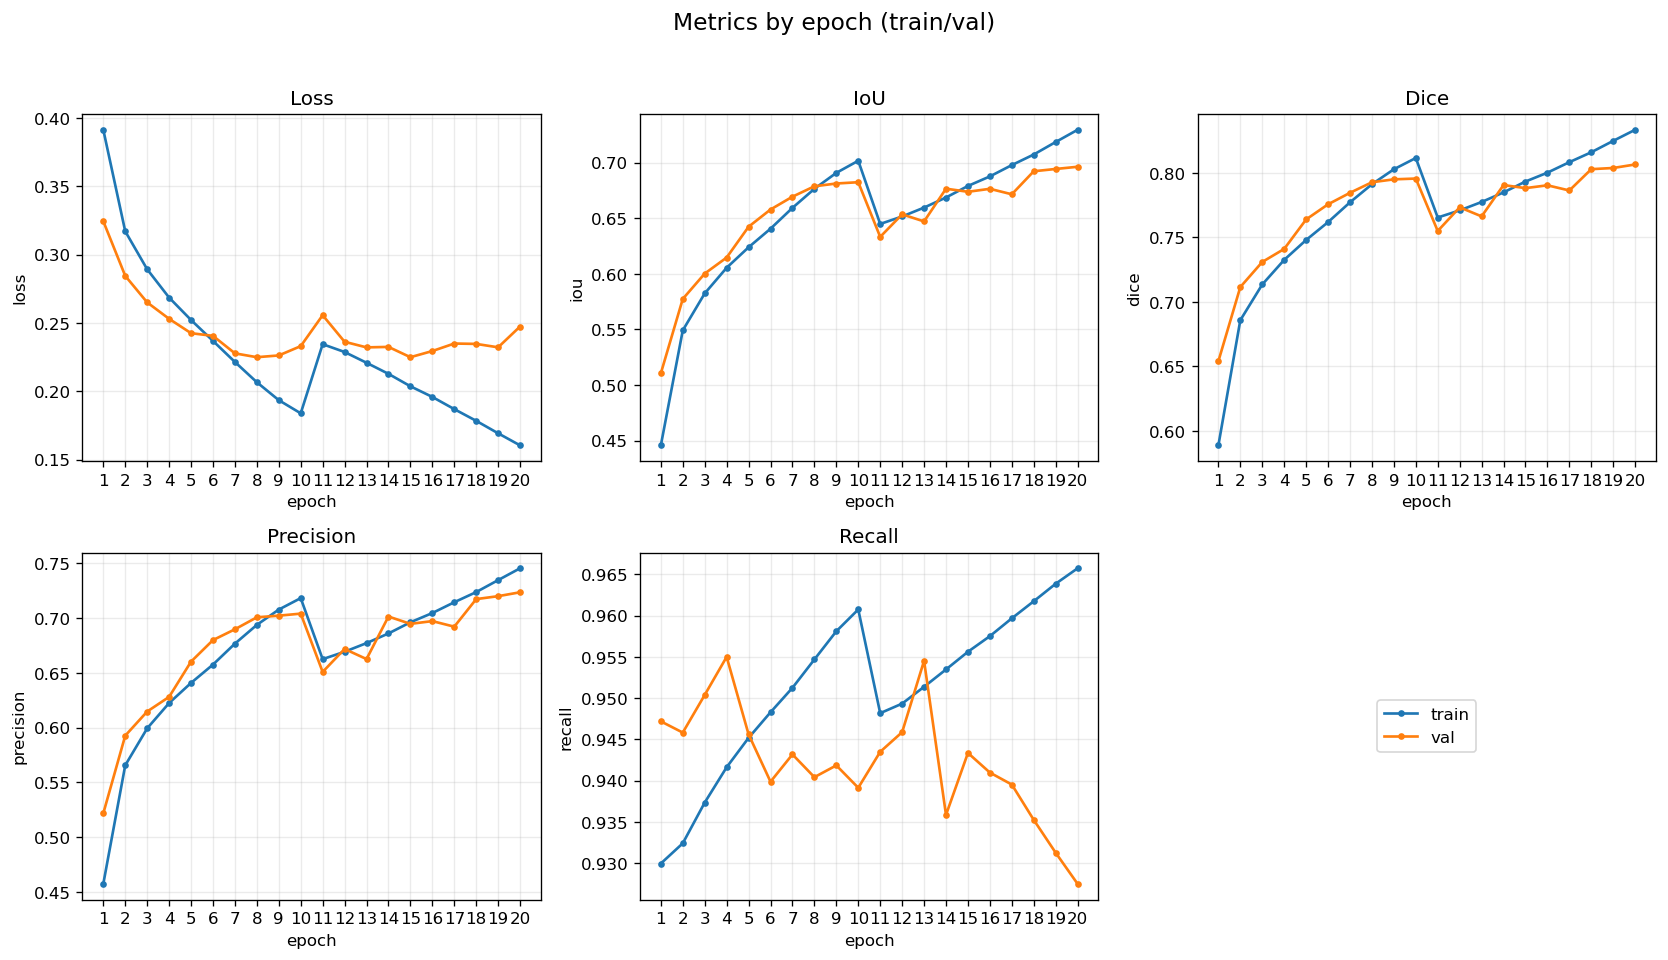

In [210]:
def _prep_epochs_int(dfm: pd.DataFrame) -> pd.DataFrame:
    df = dfm.copy()
    df["epoch"] = pd.to_numeric(df["epoch"], errors="coerce")
    df = df.dropna(subset=["epoch"]).sort_values("epoch").reset_index(drop=True)
    df["epoch"] = df["epoch"].astype(int)
    return df

def plot_metrics_panel(dfm: pd.DataFrame):
    df = _prep_epochs_int(dfm)
    epochs = df["epoch"].to_numpy()

    metrics = [
        ("loss",      "Loss"),
        ("iou",       "IoU"),
        ("dice",      "Dice"),
        ("precision", "Precision"),
        ("recall",    "Recall"),
    ]

    fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(14, 7.8), dpi=120)
    axs = axs.ravel()

    for i, (m, title) in enumerate(metrics):
        ax = axs[i]
        y_train = pd.to_numeric(df[f"train_{m}"], errors="coerce").to_numpy()
        y_val   = pd.to_numeric(df[f"val_{m}"],   errors="coerce").to_numpy()

        ax.plot(epochs, y_train, marker="o", linewidth=1.6, markersize=3, label="train")
        ax.plot(epochs, y_val,   marker="o", linewidth=1.6, markersize=3, label="val")

        ax.set_title(title)
        ax.set_xlabel("epoch")
        ax.set_ylabel(m)
        ax.grid(True, alpha=0.25)

        # эпохи как целые на тиках
        ax.set_xticks(epochs)
        ax.tick_params(axis="x", labelrotation=0)

    # 6-я ячейка — легенда
    legend_ax = axs[5]
    legend_ax.axis("off")
    handles, labels = axs[0].get_legend_handles_labels()
    legend_ax.legend(handles, labels, loc="center", frameon=True)

    fig.suptitle("Metrics by epoch (train/val)", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_metrics_panel(dfm)

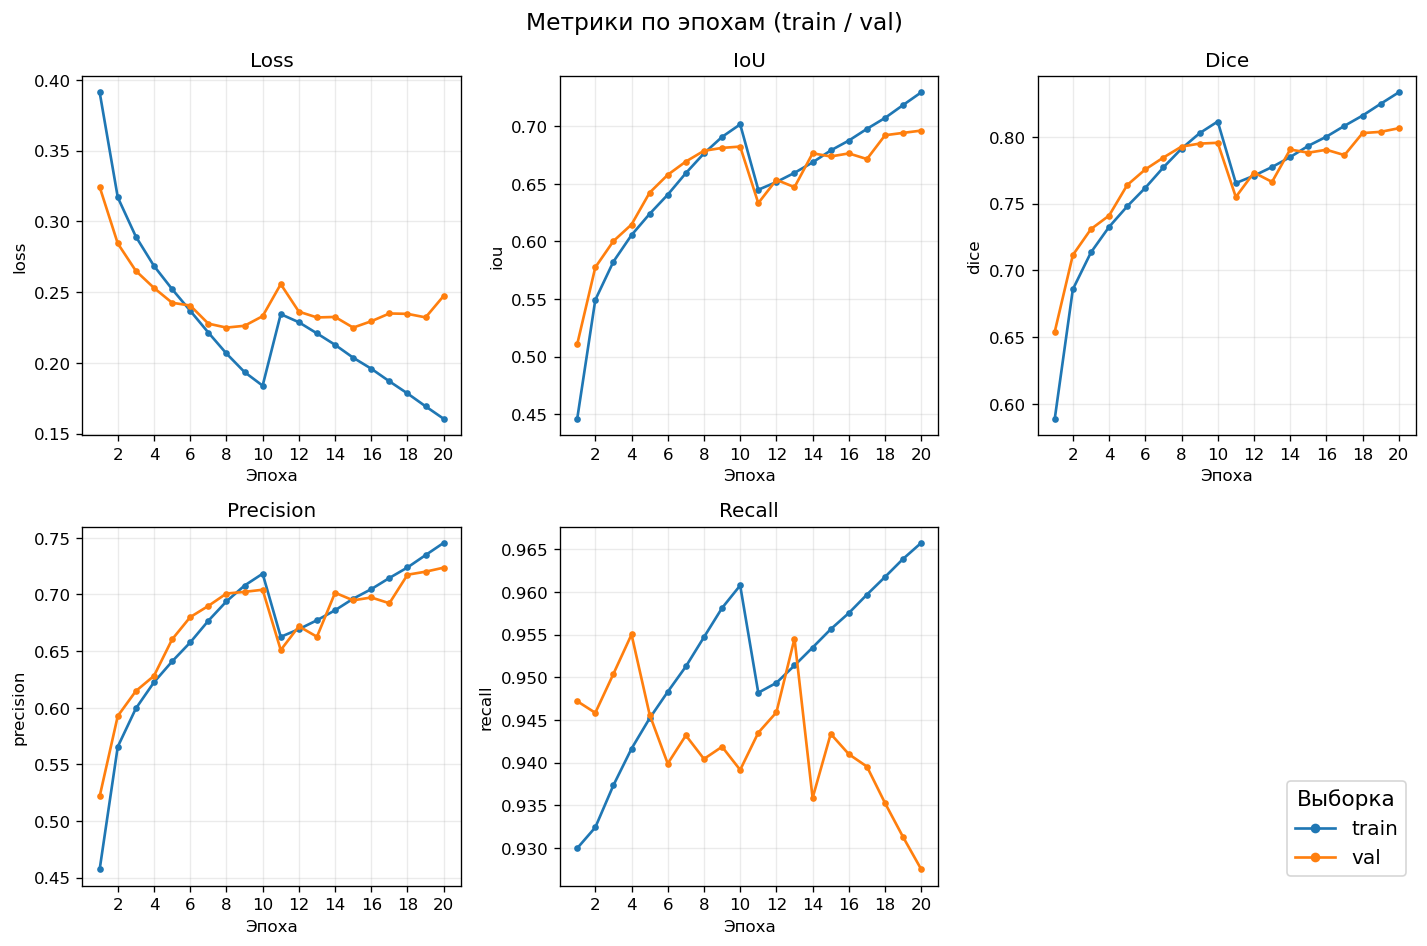

In [219]:
def plot_metrics_panel(dfm: pd.DataFrame):
    df = _prep_epochs_int(dfm)
    epochs = df["epoch"].to_numpy()

    metrics = [
        ("loss",      "Loss"),
        ("iou",       "IoU"),
        ("dice",      "Dice"),
        ("precision", "Precision"),
        ("recall",    "Recall"),
    ]

    fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(12, 8), dpi=120)
    axs = axs.ravel()

    # эпохи для подписей через одну
    xticks = epochs[1::2]

    for i, (m, title) in enumerate(metrics):
        ax = axs[i]
        y_train = pd.to_numeric(df[f"train_{m}"], errors="coerce").to_numpy()
        y_val   = pd.to_numeric(df[f"val_{m}"],   errors="coerce").to_numpy()

        ax.plot(epochs, y_train, marker="o", linewidth=1.6, markersize=3, label="train")
        ax.plot(epochs, y_val,   marker="o", linewidth=1.6, markersize=3, label="val")

        ax.set_title(title)
        ax.set_xlabel("Эпоха")
        ax.set_ylabel(m)
        ax.grid(True, alpha=0.25)

        ax.set_xticks(xticks)
        ax.tick_params(axis="x", labelrotation=0)

    # 6-я ячейка — легенда
    legend_ax = axs[5]
    legend_ax.axis("off")

    handles, labels = axs[0].get_legend_handles_labels()
    legend_ax.legend(
        handles,
        labels,
        loc="lower right",
        frameon=True,
        fontsize=12,
        title="Выборка",
        title_fontsize=13,
        markerscale=1.6,
    )

    fig.suptitle("Метрики по эпохам (train / val)", fontsize=14)
    plt.tight_layout()

    plt.savefig(f"{save_path}/metrics.png", dpi=200, bbox_inches="tight", pad_inches=0.1)
    plt.savefig(f"{save_path}/metrics.pdf", dpi=200, bbox_inches="tight", pad_inches=0.1)

    plt.show()

plot_metrics_panel(dfm)

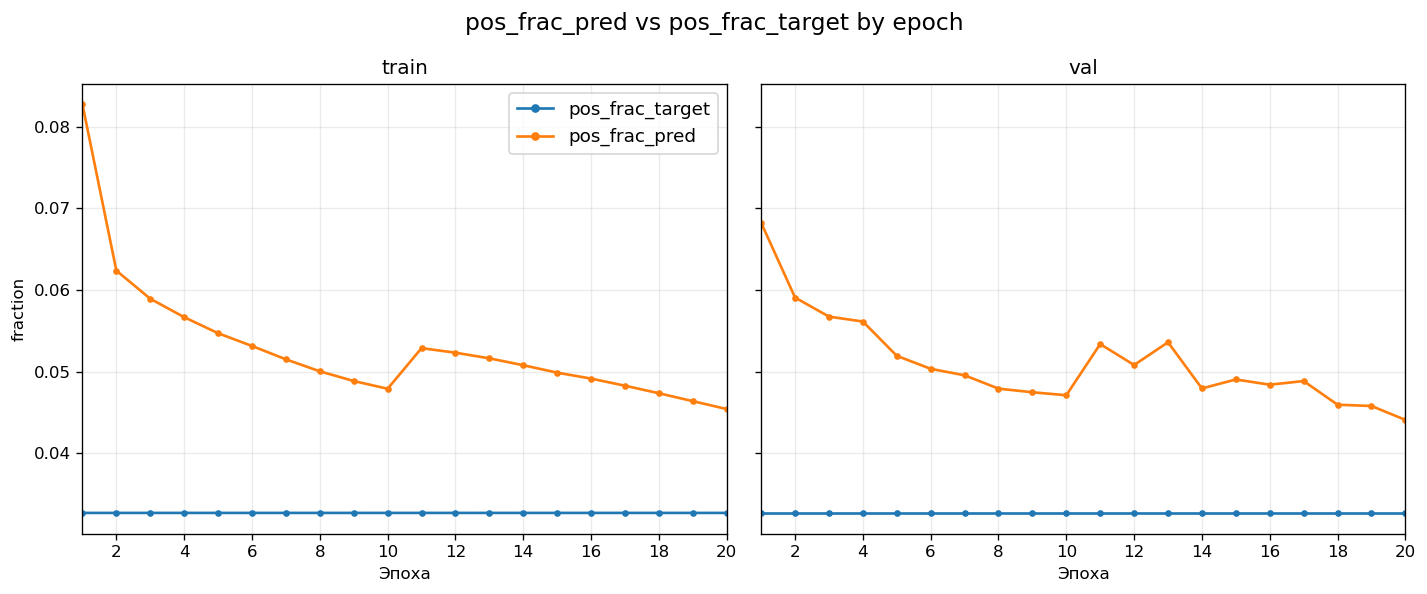

In [223]:
def plot_pos_frac_panel(dfm: pd.DataFrame):
    df = dfm.copy()
    df["epoch"] = pd.to_numeric(df["epoch"], errors="coerce")
    df = df.dropna(subset=["epoch"]).sort_values("epoch").reset_index(drop=True)
    df["epoch"] = df["epoch"].astype(int)

    epochs = df["epoch"].to_numpy()

    # эпохи для подписей через одну
    xticks = epochs[1::2]

    fig, axs = plt.subplots(
        nrows=1, ncols=2,
        figsize=(12, 5),
        dpi=120,
        sharex=True,
        sharey=True
    )

    for ax, split in zip(axs, ["train", "val"]):
        target_col = f"{split}_pos_frac_target"
        pred_col   = f"{split}_pos_frac_pred"

        y_target = pd.to_numeric(df[target_col], errors="coerce").to_numpy()
        y_pred   = pd.to_numeric(df[pred_col],   errors="coerce").to_numpy()

        ax.plot(
            epochs, y_target,
            marker="o", linewidth=1.6, markersize=3,
            label="pos_frac_target"
        )
        ax.plot(
            epochs, y_pred,
            marker="o", linewidth=1.6, markersize=3,
            label="pos_frac_pred"
        )

        ax.set_title(split)
        ax.set_xlabel("Эпоха")
        ax.grid(True, alpha=0.25)

        ax.set_xticks(xticks)
        ax.tick_params(axis="x", labelrotation=0)

        ax.set_xlim(epochs.min(), epochs.max())

    axs[0].set_ylabel("fraction")

    # одна общая легенда
    handles, labels = axs[0].get_legend_handles_labels()
    axs[0].legend(
        handles, labels,
        loc="best",
        fontsize=11,
        title="",
        markerscale=1.4
    )

    fig.suptitle("pos_frac_pred vs pos_frac_target by epoch", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{save_path}/metrics_additional.png", dpi=200, bbox_inches="tight", pad_inches=0.1)
    plt.savefig(f"{save_path}/metrics_additional.pdf", dpi=200, bbox_inches="tight", pad_inches=0.1)
    plt.show()


plot_pos_frac_panel(dfm)
